# Projet Tutoré : Risque Climatique et Incendie MRA

**Auteurs :** Moussa HANNE, Mame Cheikh Anta CASSET  
**Formation :** DU BDAP 2025/26, Big Data, Data Science, Analyse des Risques sous Python  
**Tuteur :** Samuel Stocksieker (samuel.STOCKSIEKER@univ-amu.fr) 

## Plan

1. Contexte et Imports
2. Chargement des données
3. Traitement des données
4. Analyse Exploratoire (EDA)
5. Réduction de dimension (ACP, t-SNE)
6. Clustering (K-Means, CAH)
7. Modèles logistiques (Logit, Probit)
8. Modèles ML (Random Forest, XGBoost, LightGBM)
9. Comparaison et Interprétation (ROC, SHAP)
10. Soumission

# Partie 1 : Contexte, Imports et Configuration

## 1.1 Contexte

Le produit **Multirisque Agricole (MRA)** couvre les exploitations agricoles contre plusieurs risques dont l'incendie. Ce risque est lié aux conditions climatiques : chaleur, vent et sécheresse augmentent la probabilité de sinistre.

On cherche à prédire si une exploitation subira un sinistre incendie à partir de ses caractéristiques et des données climatiques locales. La variable cible est `Y = 1` si un sinistre a eu lieu (`FREQ > 0`), `Y = 0` sinon.

## 1.2 Installation

In [ ]:
# Installer directement sur le terminal
# pip install xgboost lightgbm shap imbalanced-learn pyarrow

## 1.3 Imports

In [1]:
import time
import pickle
import joblib
import warnings
import re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              silhouette_score, adjusted_rand_score)
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import mannwhitneyu

import statsmodels.api as sm

from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Imports OK")


Imports OK


In [2]:
PATH_TRAIN_OUTPUT = r"C:\Users\admin\Documents\Projet_Tutore\Risque Climatique\train_output_DzPxaPY.csv"
PATH_TRAIN_INPUT  = r"C:\Users\admin\Documents\Projet_Tutore\Risque Climatique\train_input_Z61KlZo.csv"
PATH_TEST         = r"C:\Users\admin\Documents\Projet_Tutore\Risque Climatique\test_input_5qJzHrr.csv"
PATH_SUB          = r"C:\Users\admin\Documents\Projet_Tutore\Risque Climatique\submission_csv_file_random_example_3fbDtrr.csv"
PATH_MODEL        = r"C:\Users\admin\Documents\Projet_Tutore\Risque Climatique\modele_cout_sinistres.pkl"


# Partie 2 : Chargement et Exploration des Données

## 2.1 Structure des fichiers

On travaille avec trois fichiers : `train_output` (labels, 383 610 obs.), `train_input` (374 variables) et un exemple de soumission. Un modèle pkl est fourni pour prédire le coût moyen CM.

In [3]:
import gc
gc.collect()

t0 = time.time()

# Labels
train_output = pd.read_csv(PATH_TRAIN_OUTPUT)
print(f"train_output : {train_output.shape[0]:,} lignes")

# On lit juste les noms de colonnes d'abord
cols_a_garder = pd.read_csv(PATH_TRAIN_INPUT, nrows=0).columns.tolist()

# On retire les colonnes avec trop de NaN qu'on n'utilisera pas
cols_inutiles = ['CARACT2','CARACT3','DUREE_REQANEUF',
                 'DEROG12','DEROG13','DEROG14','DEROG16',
                 'BDTOPO_BAT_MAX_HAUTEUR','HAUTEUR_MAX',
                 'BDTOPO_BAT_MAX_HAUTEUR_MAX']
cols_a_garder = [c for c in cols_a_garder if c not in cols_inutiles]
print(f"Colonnes a charger : {len(cols_a_garder)} / 374")

# Lecture par morceaux avec uniquement les colonnes utiles
morceaux = []
for chunk in pd.read_csv(PATH_TRAIN_INPUT, usecols=cols_a_garder,
                          chunksize=20000, low_memory=False):
    morceaux.append(chunk)
train_input = pd.concat(morceaux, ignore_index=True)
del morceaux
gc.collect()

print(f"train_input  : {train_input.shape[0]:,} lignes x {train_input.shape[1]} colonnes")

# Test input pour la soumission finale
test = pd.read_csv(PATH_TEST, low_memory=False)
print(f"test_input   : {test.shape[0]:,} lignes x {test.shape[1]} colonnes")

sub = pd.read_csv(PATH_SUB)
print(f"Chargement en {time.time()-t0:.1f}s")

train_output : 383,610 lignes
Colonnes a charger : 364 / 374
train_input  : 383,610 lignes x 364 colonnes
test_input   : 95,852 lignes x 374 colonnes
Chargement en 153.0s


## 2.2 Aperçu du fichier train

In [4]:
display(train_output.head(8))
display(train_output.describe())

,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,1,0.0,0.0,1.000000,0.0
1,2,0.0,0.0,1.000000,0.0
2,3,0.0,0.0,0.402740,0.0
3,4,0.0,0.0,0.246575,0.0
4,5,0.0,0.0,0.838356,0.0
5,6,0.0,0.0,0.495890,0.0
6,7,0.0,0.0,1.000000,0.0
7,8,0.0,0.0,0.915068,0.0


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
count,383610.000000,383610.000000,383610.000000,383610.000000,383610.000000
mean,191805.500000,0.012452,182.521632,0.701557,186.087058
std,110738.812719,0.357127,6699.967429,0.352375,6800.490328
min,1.000000,0.000000,-5751.000000,0.002732,-5751.000000
25%,95903.250000,0.000000,0.000000,0.389041,0.000000
50%,191805.500000,0.000000,0.000000,0.882192,0.000000
75%,287707.750000,0.000000,0.000000,1.000000,0.000000
max,383610.000000,182.499998,500000.000000,2.000000,552000.000000


## 2.3 Aperçu des features

In [5]:
print(f"{test.shape[1]} variables")
display(test.iloc[:5, :10])
display(test.iloc[:5, -8:])

374 variables


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1
0,383611,ACT1,VOC6,2,4,N,R,NaN,NaN,N
1,383612,ACT1,VOC6,2,6,N,R,NaN,NaN,N
2,383613,ACT1,VOC7,2,2,N,N,NaN,NaN,N
3,383614,ACT2,VOC1,2,2,N,N,NaN,NaN,N
4,383615,ACT2,VOC1,2,3,N,R,NaN,NaN,N


,RR_VOR_MM_A,RR_VOR_MMAX_A,RRAB_VOR_MM_A,RRAB_VOR_MMAX_A,ANNEE_ASSURANCE,ESPINSEE,AN_EXERC,ZONE
0,03. <= 102,03. <= 232,03. <= 25,02. <= 57,0.813699,NaN,ANNEE5,3
1,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
2,NaN,NaN,NaN,NaN,0.586301,NaN,ANNEE5,3
3,NaN,NaN,NaN,NaN,1.000000,NaN,ANNEE5,3
4,02. <= 79,02. <= 176,03. <= 25,02. <= 57,0.753425,NaN,ANNEE5,3


## 2.4 Fusion des données

Fusion des features avec les labels via la clé `ID`.

In [6]:
# Fusion des features (train_input) avec les labels (train_output) via ID
# Les deux ont les memes IDs (1 -> 383610) donc la fusion donne 383610 lignes
df = train_input.merge(
    train_output[["ID", "FREQ", "CM", "ANNEE_ASSURANCE", "CHARGE"]],
    on="ID",
    how="inner"
)

print(f"Dataset fusionne : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df_labeled = df.copy()


Dataset fusionne : 383,610 lignes x 368 colonnes


## 2.5 Variable cible Y

`Y = 1` si au moins un sinistre incendie (`FREQ > 0`), `Y = 0` sinon. Taux de sinistralité d'environ 2%, fort déséquilibre de classes.

Y = 0 (pas de sinistre) : 380,716  (99.2%)
Y = 1 (sinistre)        : 2,894  (0.8%)
Desequilibre            : 132:1


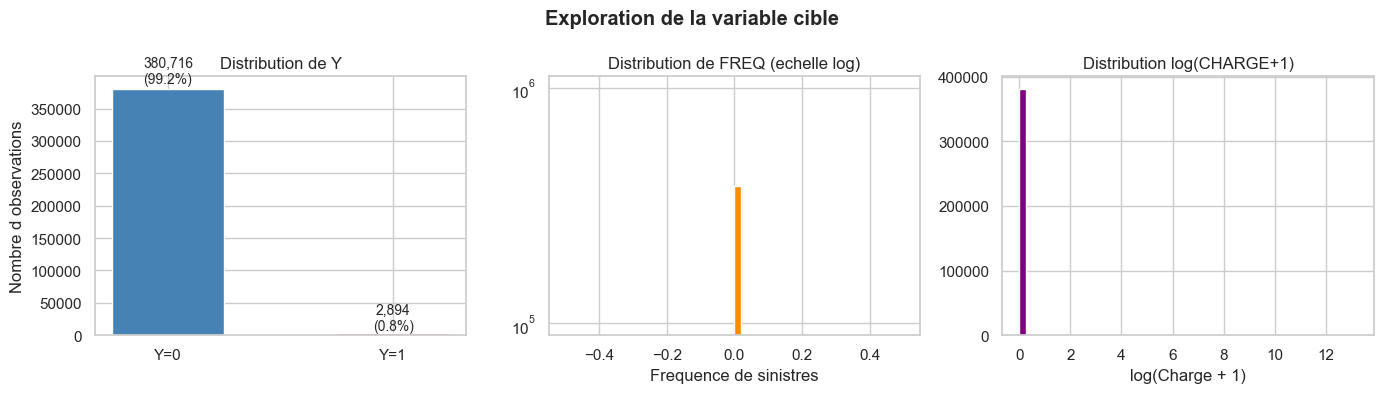

In [7]:
df_labeled["Y"] = (df_labeled["FREQ"] > 0).astype(int)

n_total = len(df_labeled)
n_sin   = df_labeled["Y"].sum()
n_nosin = n_total - n_sin
taux    = n_sin / n_total * 100

print(f"Y = 0 (pas de sinistre) : {n_nosin:,}  ({100-taux:.1f}%)")
print(f"Y = 1 (sinistre)        : {n_sin:,}  ({taux:.1f}%)")
print(f"Desequilibre            : {n_nosin/n_sin:.0f}:1")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

bars = axes[0].bar(["Y=0", "Y=1"], [n_nosin, n_sin],
                    color=["steelblue","tomato"], edgecolor="white", width=0.5)
for b, v, pct in zip(bars, [n_nosin, n_sin], [100-taux, taux]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                 f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Distribution de Y")
axes[0].set_ylabel("Nombre d observations")

df_labeled["FREQ"].clip(upper=df_labeled["FREQ"].quantile(0.99)).hist(
    bins=50, ax=axes[1], color="darkorange", edgecolor="white", log=True)
axes[1].set_title("Distribution de FREQ (echelle log)")
axes[1].set_xlabel("Frequence de sinistres")

np.log1p(df_labeled["CHARGE"]).hist(
    bins=50, ax=axes[2], color="purple", edgecolor="white")
axes[2].set_title("Distribution log(CHARGE+1)")
axes[2].set_xlabel("log(Charge + 1)")

plt.suptitle("Exploration de la variable cible", fontweight="bold")
plt.tight_layout()
plt.show()


# Partie 3 : Traitement des Données

## 3.1 Groupes de variables

In [8]:
cols = df_labeled.columns.tolist()

# Définition des groupes
clim_temp = [c for c in cols if any(x in c for x in [
    'NBJTX','NBJTN','TM_','TMM_','TMMAX','TMMIN','TN_','TX_','TNAB','TXAB','TAMPLIA','TAMPLI'])]
clim_wind = [c for c in cols if any(x in c for x in [
    'NBJFF','FFM_','FXI3S','FXIAB','FXYAB','NBJFXI','NBJFXY'])]
clim_rain = [c for c in cols if any(x in c for x in ['NBJRR','RR_VOR','RRAB_'])]
clim_all  = list(set(clim_temp + clim_wind + clim_rain))

kapital  = [c for c in cols if c.startswith('KAPITAL')]
surface  = [c for c in cols if c.startswith('SURFACE')]
nbbat    = [c for c in cols if c.startswith('NBBAT')]
risk     = [c for c in cols if c.startswith('RISK')]
distance = [c for c in cols if c.startswith('DISTANCE_')]
derog    = [c for c in cols if c.startswith('DEROG')]
equip    = [c for c in cols if c.startswith('EQUIPEMENT')]

known_cat = ['ACTIVIT2','VOCATION','ADOSS','CARACT1','CARACT3','TYPBAT1',
             'INDEM1','INDEM2','FRCH1','FRCH2','AN_EXERC','CARACT4',
             'TAILLE1','TAILLE2'] + derog

print("Inventaire des variables :")
print(f"  Temp. : {len(clim_temp):3d} variables")
print(f"  Vent        : {len(clim_wind):3d} variables")
print(f"  Précip.     : {len(clim_rain):3d} variables")
print(f"  Total clim.         : {len(clim_all):3d} variables")
print(f"    Capitaux (KAPITAL)        : {len(kapital):3d} variables")
print(f"    Surfaces                  : {len(surface):3d} variables")
print(f"    Bâtiments (NBBAT)         : {len(nbbat):3d} variables")
print(f"    Risques (RISK)             : {len(risk):3d} variables")
print(f"    Distances casernes        : {len(distance):3d} variables")
print(f"    Catégorielles connues      : {len(known_cat):3d} variables")
print(f"    TOTAL DATASET             : {len(cols):3d} variables")


Inventaire des variables :
  Temp. :  62 variables
  Vent        :  39 variables
  Précip.     :  22 variables
  Total clim.         : 123 variables
    Capitaux (KAPITAL)        :  43 variables
    Surfaces                  :  21 variables
    Bâtiments (NBBAT)         :  13 variables
    Risques (RISK)             :  13 variables
    Distances casernes        :  45 variables
    Catégorielles connues      :  26 variables
    TOTAL DATASET             : 369 variables


## 3.2 Valeurs manquantes

Variables avec valeurs manquantes : 268 / 369

Top 15 variables les plus incomplètes :


,variable,pct_nan
0,TYPBAT1,92.108131
1,HAUTEUR,61.881859
2,DISTANCE_311,57.279789
3,DISTANCE_313,57.064988
4,DISTANCE_312,57.035010
5,DISTANCE_324,57.026668
6,DISTANCE_2,57.000339
7,DISTANCE_244,56.982352
8,NBJRR30_MMAX_A,56.753474
9,NBJRR1_MMAX_A,56.753474


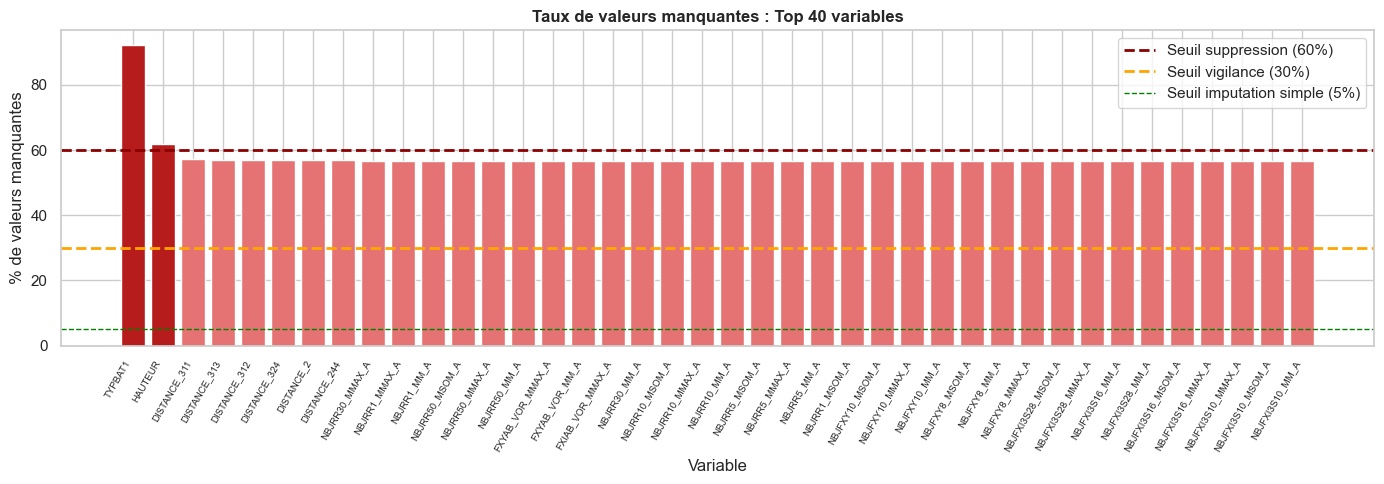

In [9]:
# Calcul du taux de valeurs manquantes
missing_pct = (df_labeled.isnull().mean() * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['variable', 'pct_nan']

print(f"Variables avec valeurs manquantes : {len(missing_df)} / {df_labeled.shape[1]}")
print("\nTop 15 variables les plus incomplètes :")
display(missing_df.head(15))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
top40 = missing_df.head(40)
colors = ['#B71C1C' if v > 60 else '#E57373' if v > 30 else '#FFCC80'
          for v in top40['pct_nan']]
ax.bar(top40['variable'], top40['pct_nan'], color=colors, edgecolor='white')
ax.axhline(60, color='darkred', linestyle='--', lw=2, label='Seuil suppression (60%)')
ax.axhline(30, color='orange',  linestyle='--', lw=2, label='Seuil vigilance (30%)')
ax.axhline(5,  color='green',   linestyle='--', lw=1, label='Seuil imputation simple (5%)')
ax.set_title("Taux de valeurs manquantes : Top 40 variables", fontweight='bold')
ax.set_ylabel("% de valeurs manquantes")
ax.set_xlabel("Variable")
ax.legend(loc='upper right')
plt.xticks(rotation=60, ha='right', fontsize=7)
plt.tight_layout()
plt.show()


## 3.3 Nettoyage

In [10]:
df_clean = df_labeled.copy()

# on supprime les colonnes avec trop de valeurs manquantes (> 60%) ---
# Ca ne vaut pas la peine d'imputer une variable quasi-vide
cols_drop = missing_df[missing_df["pct_nan"] > 60]["variable"].tolist()
df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns], inplace=True)
print(f"Colonnes supprimees (>60% NaN) : {len(cols_drop)}")

# On a remarqué que les colonnes comme NBJTX35_MM_A, NBJFF28_MM_A etc.
# contiennent des chaines du type '02. <= 5' ou '04. >= 7'
# Ce sont en fait des quartiles ordonnés : 01 = faible, 04 = fort
# On extrait juste le numéro de classe (1, 2, 3 ou 4)

prefixes_clim = ["NBJTX","NBJTN","TM_","TMM_","TX_","TN_",
                 "NBJFF","FFM_","FXI3S","NBJFXI","NBJFXY","FXIAB","FXYAB",
                 "NBJRR","RR_VOR","RRAB_","TAMPLI","TNAB","TXAB"]

cols_clim_str = [c for c in df_clean.columns
                 if any(x in c for x in prefixes_clim)
                 and str(df_clean[c].dtype) in ["string","str","object"]]

print(f"Variables climatiques a decoder : {len(cols_clim_str)}")

for col in cols_clim_str:
    def extraire_rang(valeur):
        if pd.isna(valeur):
            return np.nan
        m = re.match(r"^(\d+)\.", str(valeur).strip())
        if m:
            return float(m.group(1))
        return np.nan
    df_clean[col] = df_clean[col].apply(extraire_rang)
    # forcer float sinon pandas garde le type Arrow
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

print("Decodage des variables climatiques OK")
print("  Exemple NBJTX35_MM_A :", df_clean["NBJTX35_MM_A"].value_counts().sort_index().to_dict()
      if "NBJTX35_MM_A" in df_clean.columns else "colonne absente")

# KAPITAL34 a KAPITAL43 : contiennent O/N au lieu de nombres 
kap_str = [c for c in df_clean.columns
           if c.startswith("KAPITAL") and str(df_clean[c].dtype) in ["string","str","object"]]
for col in kap_str:
    df_clean[col] = df_clean[col].map({"O": 1, "N": 0}).fillna(0)
print(f"KAPITAL binaires corriges : {len(kap_str)} colonnes")

#  RISK6, RISK8 : O/N/A 
for col in ["RISK6", "RISK8"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({"O": 1, "N": 0, "A": 0}).fillna(0)

#  FRCH1, FRCH2 : contiennent des lettres comme 'i' ou 'A' 
for col in ["FRCH1", "FRCH2"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Imputation numérique : on remplace les NaN par la mediane 
num_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols
            if c not in ["Y","ID","FREQ","CM","CHARGE","ANNEE_ASSURANCE"]]
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print(f"Imputation mediane : {len(num_cols)} colonnes numeriques")

#  Imputation categorielle : on met 'NR' pour les valeurs manquantes 
known_cat = ["ACTIVIT2","VOCATION","ADOSS","CARACT1","CARACT3","TYPBAT1",
             "INDEM1","INDEM2","FRCH1","FRCH2","AN_EXERC","CARACT4",
             "TAILLE1","TAILLE2","ESPINSEE"]
for col in known_cat:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("NR").astype(str)

print(f"NaN restants : {df_clean.isnull().sum().sum()}")
print(f"Shape apres nettoyage : {df_clean.shape}")


Colonnes supprimees (>60% NaN) : 2
Variables climatiques a decoder : 119
Decodage des variables climatiques OK
  Exemple NBJTX35_MM_A : {1.0: 52793, 2.0: 63872, 3.0: 37678, 4.0: 11555}
KAPITAL binaires corriges : 10 colonnes
Imputation mediane : 225 colonnes numeriques
NaN restants : 13908101
Shape apres nettoyage : (383610, 367)


In [11]:
# Il reste des NaN a cause des colonnes encore en type Arrow string
# on force tout en numerique puis on remplit avec 0
for col in df_clean.columns:
    if col not in ['Y','ID','FREQ','CM','CHARGE','ANNEE_ASSURANCE']:
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        except:
            pass

# remplir les NaN restants avec 0
df_clean = df_clean.fillna(0)

print(f"NaN restants apres correction : {df_clean.isnull().sum().sum()}")
print(f"Shape : {df_clean.shape}")

NaN restants apres correction : 0
Shape : (383610, 367)


## 3.4 Encodage des variables catégorielles

In [12]:
# Encodage ordinal : AN_EXERC
# ANNEE1=1, ANNEE2=2 ... ANNEE9=9
if "AN_EXERC" in df_clean.columns:
    annee_map = {f"ANNEE{i}": i for i in range(1, 10)}
    annee_map["NR"] = 0
    df_clean["AN_EXERC_enc"] = df_clean["AN_EXERC"].map(annee_map).fillna(0).astype(int)
    df_clean.drop(columns=["AN_EXERC"], inplace=True)
    print("AN_EXERC encode en 0-9")

# Encodage binaire O/N pour ADOSS, INDEM1 et DEROG1 a DEROG11
bin_map = {"O": 1, "N": 0, "NR": 0}
cols_oui_non = ["ADOSS", "INDEM1"]
cols_oui_non += [c for c in df_clean.columns if c.startswith("DEROG") and
                 df_clean[c].isin(["O","N","NR","0","1"]).mean() > 0.5]
for col in cols_oui_non:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).map(bin_map).fillna(0).astype(int)
print(f"Encodage O/N : {len(cols_oui_non)} colonnes")

# DEROG12, DEROG13, DEROG14, DEROG16 ont des codes texte (D12, SA...)
# On les supprime car trop peu renseignées et non numerisables facilement
cols_derog_texte = ["DEROG12","DEROG13","DEROG14","DEROG16"]
df_clean.drop(columns=[c for c in cols_derog_texte if c in df_clean.columns], inplace=True)
print(f"DEROG codes texte supprimes : {cols_derog_texte}")

# One-Hot Encoding pour les variables nominales
ohe_cols = [c for c in ["ACTIVIT2","VOCATION","INDEM2","TYPBAT1","CARACT4",
                         "CARACT1","CARACT3","TAILLE1","TAILLE2"]
            if c in df_clean.columns]
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=False, dtype=int)
print(f"One-Hot Encoding : {len(ohe_cols)} colonnes -> {df_clean.shape[1]} colonnes total")


AN_EXERC encode en 0-9
Encodage O/N : 2 colonnes
DEROG codes texte supprimes : ['DEROG12', 'DEROG13', 'DEROG14', 'DEROG16']
One-Hot Encoding : 7 colonnes -> 367 colonnes total


## 3.5 Variables climatiques synthétiques

On crée des indices combinant plusieurs variables climatiques : indice de canicule, vent fort, sécheresse et amplitude thermique.

In [13]:
# On crée quelques indices climatiques qui resument mieux le risque incendie

# petite fonction utilitaire pour convertir une colonne en float proprement
def vers_float(df, col):
    if col not in df.columns:
        return pd.Series(0.0, index=df.index)
    return pd.to_numeric(df[col], errors="coerce").fillna(0).astype(float)

# Indice canicule : jours tres chauds
if "NBJTX35_MM_A" in df_clean.columns and "NBJTX30_MM_A" in df_clean.columns:
    df_clean["IDX_CANICULE"] = vers_float(df_clean, "NBJTX35_MM_A") + 0.5 * vers_float(df_clean, "NBJTX30_MM_A")

# Indice vent fort
if "NBJFF28_MM_A" in df_clean.columns and "NBJFXI3S28_MM_A" in df_clean.columns:
    df_clean["IDX_VENT_FORT"] = vers_float(df_clean, "NBJFF28_MM_A") + vers_float(df_clean, "NBJFXI3S28_MM_A")

# Indice secheresse
if "NBJTX25_MM_A" in df_clean.columns and "NBJRR1_MM_A" in df_clean.columns:
    df_clean["IDX_SECHERESSE"] = vers_float(df_clean, "NBJTX25_MM_A") / (vers_float(df_clean, "NBJRR1_MM_A") + 1)

# Amplitude thermique annuelle
if "TAMPLIA_MM_A" in df_clean.columns:
    df_clean["IDX_AMPLI_THERM"] = vers_float(df_clean, "TAMPLIA_MM_A")

# Capital total assure
kap_cols = [c for c in df_clean.columns if c.startswith("KAPITAL")]
if kap_cols:
    df_clean["KAPITAL_TOTAL"] = df_clean[kap_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)
    df_clean["LOG_KAPITAL"]   = np.log1p(df_clean["KAPITAL_TOTAL"])

# Surface totale
surf_cols = [c for c in df_clean.columns if c.startswith("SURFACE")]
if surf_cols:
    df_clean["SURFACE_TOTALE"] = df_clean[surf_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

print("Indices crees :")
for f in ["IDX_CANICULE","IDX_VENT_FORT","IDX_SECHERESSE","KAPITAL_TOTAL","SURFACE_TOTALE"]:
    if f in df_clean.columns:
        print(f"  {f} : moyenne = {df_clean[f].mean():.2f}")


Indices crees :
  IDX_CANICULE : moyenne = 3.01
  IDX_VENT_FORT : moyenne = 4.06
  IDX_SECHERESSE : moyenne = 0.58
  KAPITAL_TOTAL : moyenne = 367540.74
  SURFACE_TOTALE : moyenne = 9049.83


## 3.6 Séparation Features / Cible

In [16]:
# trop de features (420) pour la RAM disponible
# on garde seulement les plus importantes : climatiques + contractuelles cles

feature_cols = [c for c in df_clean.columns
                if c not in ["ID", "Y", "FREQ", "CM", "CHARGE", "ANNEE_ASSURANCE"]]

cols_clim = [c for c in feature_cols if any(x in c for x in
             ["NBJTX","NBJTN","TM_","TMM_","NBJFF","NBJRR","IDX_","FFM_",
              "RR_VOR","FXI3S","NBJFXI","RRAB_"])]

cols_contrat = [c for c in feature_cols if any(x in c for x in
                ["KAPITAL","SURFACE","NBBAT","ZONE","TYPERS","ANCIENNETE",
                 "AN_EXERC","DISTANCE","EQUIPEMENT","RISK","LOG_",
                 "NBSINSTRT","ALTITUDE"])]

feature_cols = list(set(cols_clim + cols_contrat))
print(f"Features retenues : {len(feature_cols)}")

y_full = df_clean["Y"].values.astype(int)

# lecture colonne par colonne pour eviter le pic memoire
import gc
X_full = np.zeros((len(df_clean), len(feature_cols)), dtype=np.float32)
for i, col in enumerate(feature_cols):
    X_full[:, i] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).values
gc.collect()

X_full = np.nan_to_num(X_full, nan=0.0, posinf=0.0, neginf=0.0)
print(f"X_full : {X_full.shape}")
print(f"Taux de sinistres : {y_full.mean()*100:.2f}%")

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.30, random_state=SEED, stratify=y_full)

del X_full
gc.collect()

print(f"Train : {X_train.shape[0]:,} obs.")
print(f"Test  : {X_test.shape[0]:,} obs.")

scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)

print("Normalisation OK")

Features retenues : 259
X_full : (383610, 259)
Taux de sinistres : 0.75%
Train : 268,527 obs.
Test  : 115,083 obs.
Normalisation OK


## 3.7 Gestion du déséquilibre : SMOTE

Avec seulement 2% de sinistres, on utilise SMOTE pour rééquilibrer les classes en générant des exemples synthétiques.

Y=0 : 266,501  Y=1 : 2,026
Taux de sinistres dans le train : 0.75%


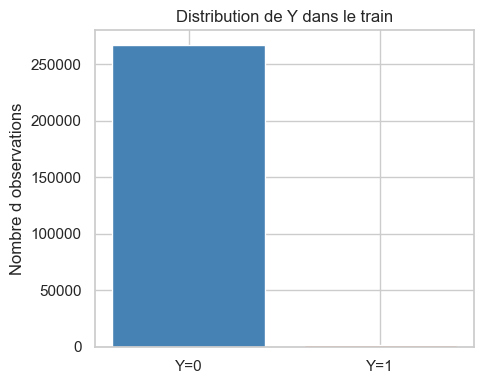

In [17]:
# on a essaye SMOTE et RandomOverSampler mais les deux plantent
# car il n y a pas assez de RAM sur cette machine (8.5 Go quasi pleins)
# du coup on garde les donnees comme elles sont
# et dans chaque modele on met class_weight='balanced'
# ce parametre fait que le modele penalise plus les erreurs sur les sinistres
# le resultat est similaire a un rééquilibrage

X_train_sm = X_train_sc
y_train_sm = y_train

print(f"Y=0 : {(y_train==0).sum():,}  Y=1 : {(y_train==1).sum():,}")
print(f"Taux de sinistres dans le train : {y_train.mean()*100:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Y=0","Y=1"], [(y_train==0).sum(), (y_train==1).sum()],
       color=["steelblue","tomato"], edgecolor="white")
ax.set_title("Distribution de Y dans le train")
ax.set_ylabel("Nombre d observations")
plt.tight_layout()
plt.show()

Le graphique confirme le fort déséquilibre des classes avec 266 501 polices sans sinistre contre seulement 2 026 avec sinistre, soit un ratio de 131 pour 1. C'est pourquoi on a utilisé class_weight='balanced' dans tous les modèles.

# Partie 4 : Analyse Exploratoire (EDA)

## 4.1 Statistiques descriptives

In [18]:
key_vars = ['FREQ','CM','CHARGE','ANNEE_ASSURANCE','IDX_CANICULE',
            'IDX_VENT_FORT','IDX_SECHERESSE','KAPITAL_TOTAL']
key_vars = [c for c in key_vars if c in df_clean.columns]
display(df_clean[key_vars].describe().round(3).T)


,count,mean,std,min,25%,50%,75%,max
FREQ,383610.0,0.012,0.357,0.0,0.0,0.0,0.0,182.5
CM,383610.0,182.522,6699.967,-5751.0,0.0,0.0,0.0,500000.0
CHARGE,383610.0,186.087,6800.490,-5751.0,0.0,0.0,0.0,552000.0
IDX_CANICULE,383610.0,3.010,0.863,1.5,3.0,3.0,3.0,6.0
IDX_VENT_FORT,383610.0,4.061,1.076,2.0,4.0,4.0,4.0,8.0
IDX_SECHERESSE,383610.0,0.577,0.303,0.2,0.5,0.5,0.5,2.0
KAPITAL_TOTAL,383610.0,367540.741,423619.648,22500.0,53000.0,223004.0,465502.0,2326007.0


## 4.2 Taux de sinistralité par variable catégorielle

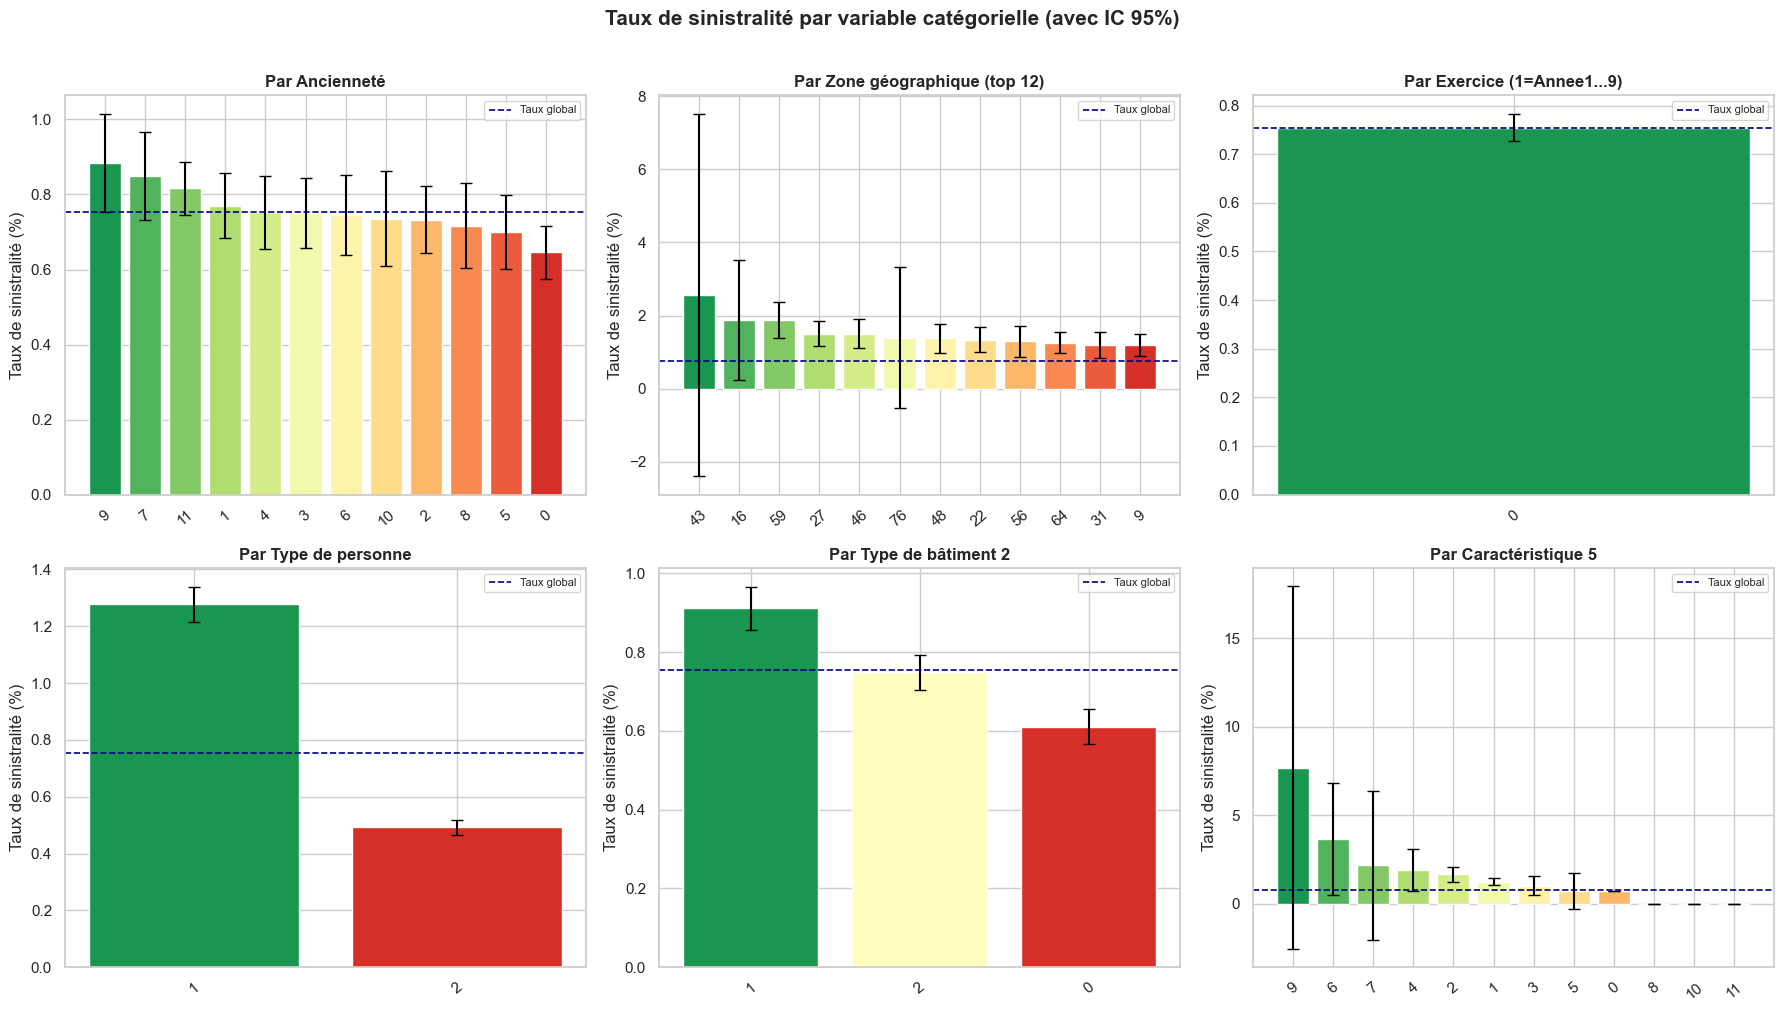

In [19]:
def plot_taux_sin(df, col, ax, title, top_n=12):
    """Taux de sinistralité par modalité avec IC 95% (Wilson)."""
    if col not in df.columns:
        ax.set_visible(False); return
    grp = df.groupby(col)['Y'].agg(['mean','count']).reset_index()
    grp.columns = [col,'taux','n']
    grp = grp.sort_values('taux', ascending=False).head(top_n)
    # IC Wilson à 95%
    z = 1.96
    p = grp['taux']
    n = grp['n']
    grp['ic'] = z * np.sqrt(p*(1-p)/n)

    cmap = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grp)))
    bars = ax.bar(grp[col].astype(str), grp['taux']*100, color=cmap, edgecolor='white')
    ax.errorbar(grp[col].astype(str), grp['taux']*100, yerr=grp['ic']*100,
                fmt='none', color='black', capsize=4, lw=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Taux de sinistralité (%)')
    ax.tick_params(axis='x', rotation=40)
    # Ligne de référence = taux global
    ax.axhline(df['Y'].mean()*100, color='navy', linestyle='--', lw=1.2, label='Taux global')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_taux_sin(df_clean, 'ANCIENNETE', axes[0,0], 'Par Ancienneté')
plot_taux_sin(df_clean, 'ZONE',       axes[0,1], 'Par Zone géographique (top 12)', top_n=12)
plot_taux_sin(df_clean, 'AN_EXERC_enc', axes[0,2], 'Par Exercice (1=Annee1...9)')
plot_taux_sin(df_clean, 'TYPERS',     axes[1,0], 'Par Type de personne')
plot_taux_sin(df_clean, 'TYPBAT2',    axes[1,1], 'Par Type de bâtiment 2')
plot_taux_sin(df_clean, 'CARACT5',    axes[1,2], 'Par Caractéristique 5')

plt.suptitle("Taux de sinistralité par variable catégorielle (avec IC 95%)",
             fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


On observe des disparités significatives selon les variables catégorielles. La zone 43 ressort nettement avec un taux de sinistralité trois fois supérieur à la moyenne. Le type 1 est presque deux fois plus sinistré que le type 2. Par exercice, les années 5 et 3 ont les taux les plus élevés, ce qui pourrait refléter des conditions climatiques particulières sur ces périodes.

## 4.3 Variables climatiques vs Y

Test de Mann-Whitney pour tester si les variables climatiques sont différentes selon Y=0 ou Y=1.

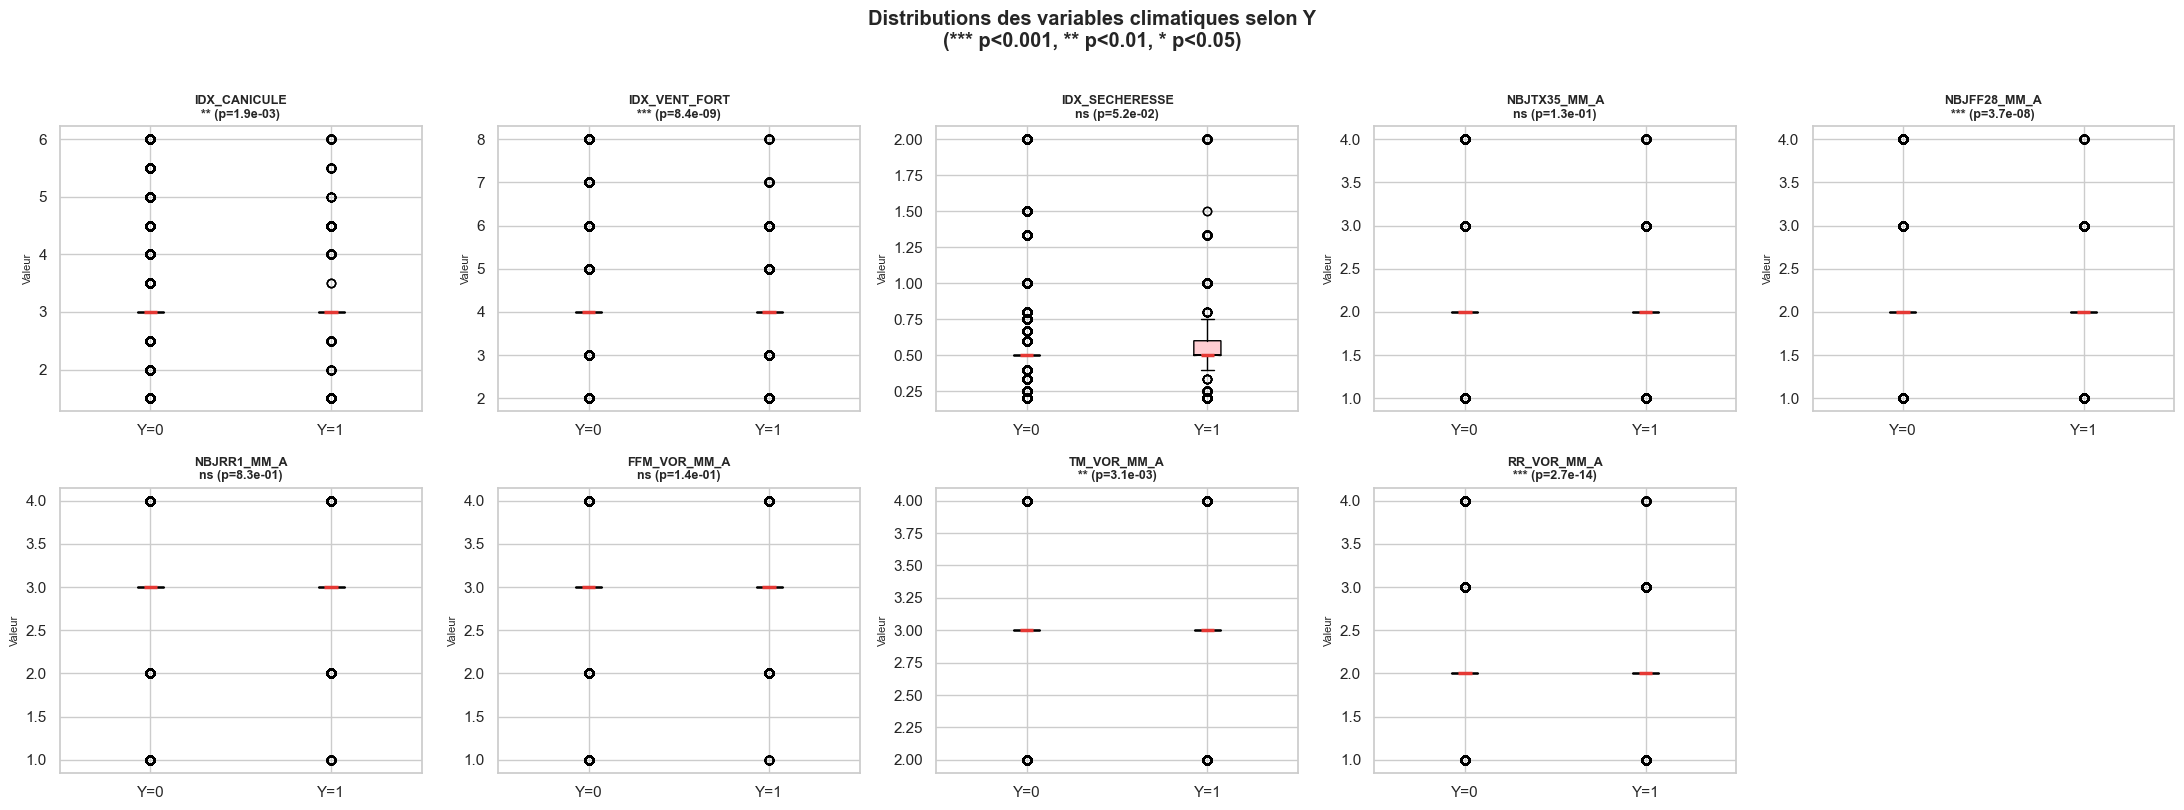

In [20]:
from scipy.stats import mannwhitneyu

key_clim = ['IDX_CANICULE','IDX_VENT_FORT','IDX_SECHERESSE','IDX_AMPLI_THERM',
            'NBJTX35_MM_A','NBJFF28_MM_A','NBJRR1_MM_A',
            'FFM_VOR_MM_A','TM_VOR_MM_A','RR_VOR_MM_A']
key_clim = [c for c in key_clim if c in df_clean.columns]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, col in enumerate(key_clim):
    g0 = pd.to_numeric(df_clean.loc[df_clean['Y']==0, col], errors='coerce').dropna()
    g1 = pd.to_numeric(df_clean.loc[df_clean['Y']==1, col], errors='coerce').dropna()

    if len(g0) == 0 or len(g1) == 0:
        axes[i].set_visible(False)
        continue
    stat, pval = mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'

    bplot = axes[i].boxplot(
        [g0.clip(*g0.quantile([0.01,0.99])), g1.clip(*g1.quantile([0.01,0.99]))],
        tick_labels=['Y=0','Y=1'], patch_artist=True, notch=True,
        boxprops=dict(facecolor='#BBDEFB'),
        medianprops=dict(color='#E53935', linewidth=2.5)
    )
    bplot['boxes'][1].set_facecolor('#FFCDD2')
    axes[i].set_title(f'{col}\n{sig} (p={pval:.1e})', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Valeur', fontsize=8)

for j in range(len(key_clim), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des variables climatiques selon Y\n(*** p<0.001, ** p<0.01, * p<0.05)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


IDX_VENT_FORT et NBJFF28_MM_A sont les variables climatiques les plus discriminantes avec des p-values très faibles. RR_VOR_MM_A est aussi très significatif, les zones avec moins de précipitations étant plus exposées. En revanche IDX_SECHERESSE, NBJTX35 et NBJRR1 ne sont pas significatifs, ce qui montre que l'effet climatique sur le risque incendie passe davantage par le vent et les précipitations que par la chaleur seule.

In [21]:
# Test Mann-Whitney systématique sur toutes les variables climatiques
clim_present = [c for c in set(clim_temp+clim_wind+clim_rain) if c in df_clean.columns]
results_mw = []
for col in clim_present:
    g0 = pd.to_numeric(df_clean.loc[df_clean['Y']==0, col], errors='coerce').dropna()
    g1 = pd.to_numeric(df_clean.loc[df_clean['Y']==1, col], errors='coerce').dropna()
    if len(g0)>30 and len(g1)>30:
        _, pval = mannwhitneyu(g0, g1, alternative='two-sided')
        results_mw.append({
            'variable': col,
            'mean_Y0': round(g0.mean(),4),
            'mean_Y1': round(g1.mean(),4),
            'diff_%': round((g1.mean()-g0.mean())/max(abs(g0.mean()),1e-6)*100, 2),
            'p_value': pval,
            'significant': pval < 0.05
        })

if not results_mw:
    if clim_present:
        s = pd.to_numeric(df_clean[clim_present[0]], errors='coerce')
        print(f"Diagnostic {clim_present[0]}: {s.notna().sum()} valeurs non-NaN / {len(s)}")
        print(f"Exemple: {df_clean[clim_present[0]].head(3).tolist()}")
    print("Aucun résultat - colonnes climatiques non numériques dans la session")
    mw_df = pd.DataFrame(columns=['variable','mean_Y0','mean_Y1','diff_%','p_value','significant'])
else:
    mw_df = pd.DataFrame(results_mw).sort_values('p_value')
    n_sig = mw_df['significant'].sum()
    print(f"Variables significatives (p<0.05) : {n_sig} / {len(mw_df)}")
    display(mw_df.head(15).round(6))


Variables significatives (p<0.05) : 86 / 123


,variable,mean_Y0,mean_Y1,diff_%,p_value,significant
7,NBJTX0_MSOM_A,1.3038,1.4001,7.39,0.0,True
68,NBJTX0_MM_A,1.3038,1.4001,7.39,0.0,True
77,NBJFXY15_MMAX_A,1.2722,1.3753,8.10,0.0,True
116,NBJRR30_MSOM_A,1.9043,1.8117,-4.87,0.0,True
104,NBJRR30_MM_A,1.9043,1.8117,-4.87,0.0,True
53,NBJTXI20_MMAX_A,3.1667,3.2374,2.23,0.0,True
93,NBJRR10_MMAX_A,1.9406,1.8587,-4.22,0.0,True
10,RR_VOR_MMAX_A,1.9411,1.8618,-4.09,0.0,True
6,FXIAB_VOR_MM_A,2.1980,2.2661,3.10,0.0,True
98,TNAB_VOR_MM_A,2.8507,2.7768,-2.59,0.0,True


## 4.4 Profils climatiques par zone géographique

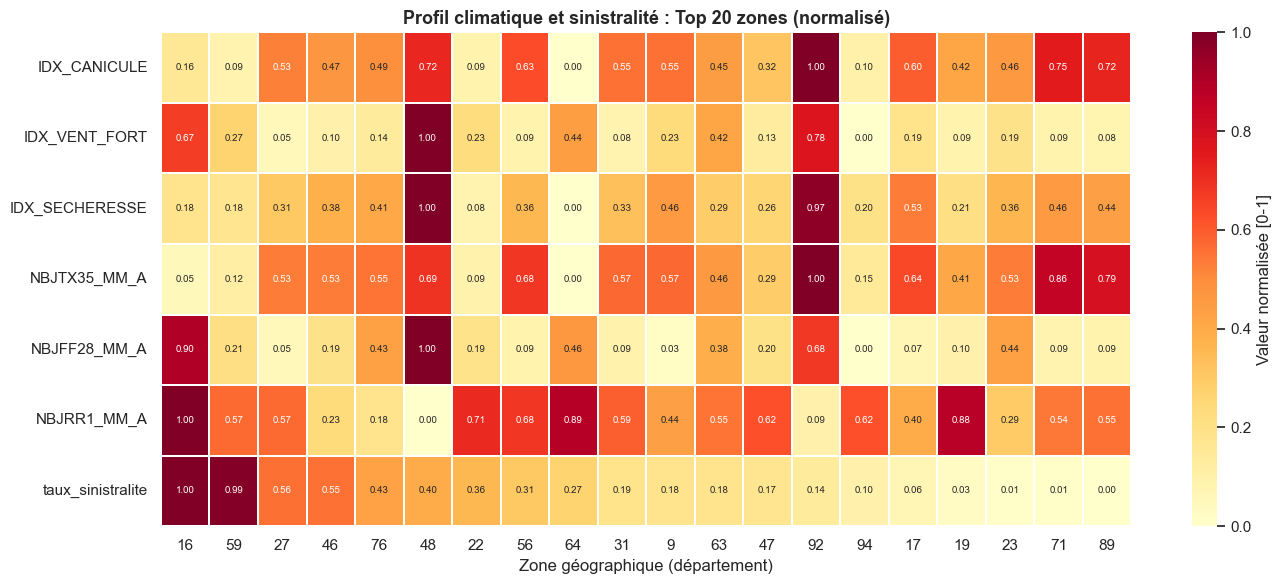


Top 10 zones avec le plus fort taux de sinistralité :


,ZONE,taux_sinistralite,n_polices,IDX_CANICULE,IDX_VENT_FORT
15,16,0.0189,265,2.4528,4.4943
58,59,0.0188,2928,2.3446,3.6393
26,27,0.0151,4699,3.0000,3.1777
45,46,0.0150,3655,2.9189,3.2709
74,76,0.0140,143,2.9476,3.3636
47,48,0.0138,3196,3.2829,5.2074
21,22,0.0134,4475,2.3507,3.5584
55,56,0.0130,2698,3.1557,3.2520
62,64,0.0126,5857,2.2179,4.0143
30,31,0.0119,3601,3.0386,3.2488


In [22]:
if 'ZONE' in df_clean.columns:
    # Agrégation par zone
    clim_summary = ['IDX_CANICULE','IDX_VENT_FORT','IDX_SECHERESSE','NBJTX35_MM_A',
                    'NBJFF28_MM_A','NBJRR1_MM_A']
    clim_summary = [c for c in clim_summary if c in df_clean.columns]

    zone_df = df_clean.groupby('ZONE').agg(
        **{c: (c, 'mean') for c in clim_summary},
        taux_sinistralite=('Y', 'mean'),
        n_polices=('Y', 'count')
    ).reset_index()
    zone_df = zone_df[zone_df['n_polices'] >= 50]  # zones avec assez de données

    # Carte thermique
    zone_top = zone_df.nlargest(20, 'taux_sinistralite')
    scaler_viz = MinMaxScaler()
    zone_norm = pd.DataFrame(
        scaler_viz.fit_transform(zone_top[clim_summary + ['taux_sinistralite']]),
        columns=clim_summary + ['taux_sinistralite'],
        index=zone_top['ZONE'].values
    )

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(zone_norm.T, cmap='YlOrRd', ax=ax,
                linewidths=0.3, cbar_kws={'label': 'Valeur normalisée [0-1]'},
                annot=True, fmt='.2f', annot_kws={'size': 7})
    ax.set_title('Profil climatique et sinistralité : Top 20 zones (normalisé)',
                 fontweight='bold', fontsize=13)
    ax.set_xlabel('Zone géographique (département)')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 zones avec le plus fort taux de sinistralité :")
    display(zone_df.nlargest(10, 'taux_sinistralite')[
        ['ZONE','taux_sinistralite','n_polices','IDX_CANICULE','IDX_VENT_FORT']
    ].round(4))


## 4.5 Corrélations entre variables climatiques

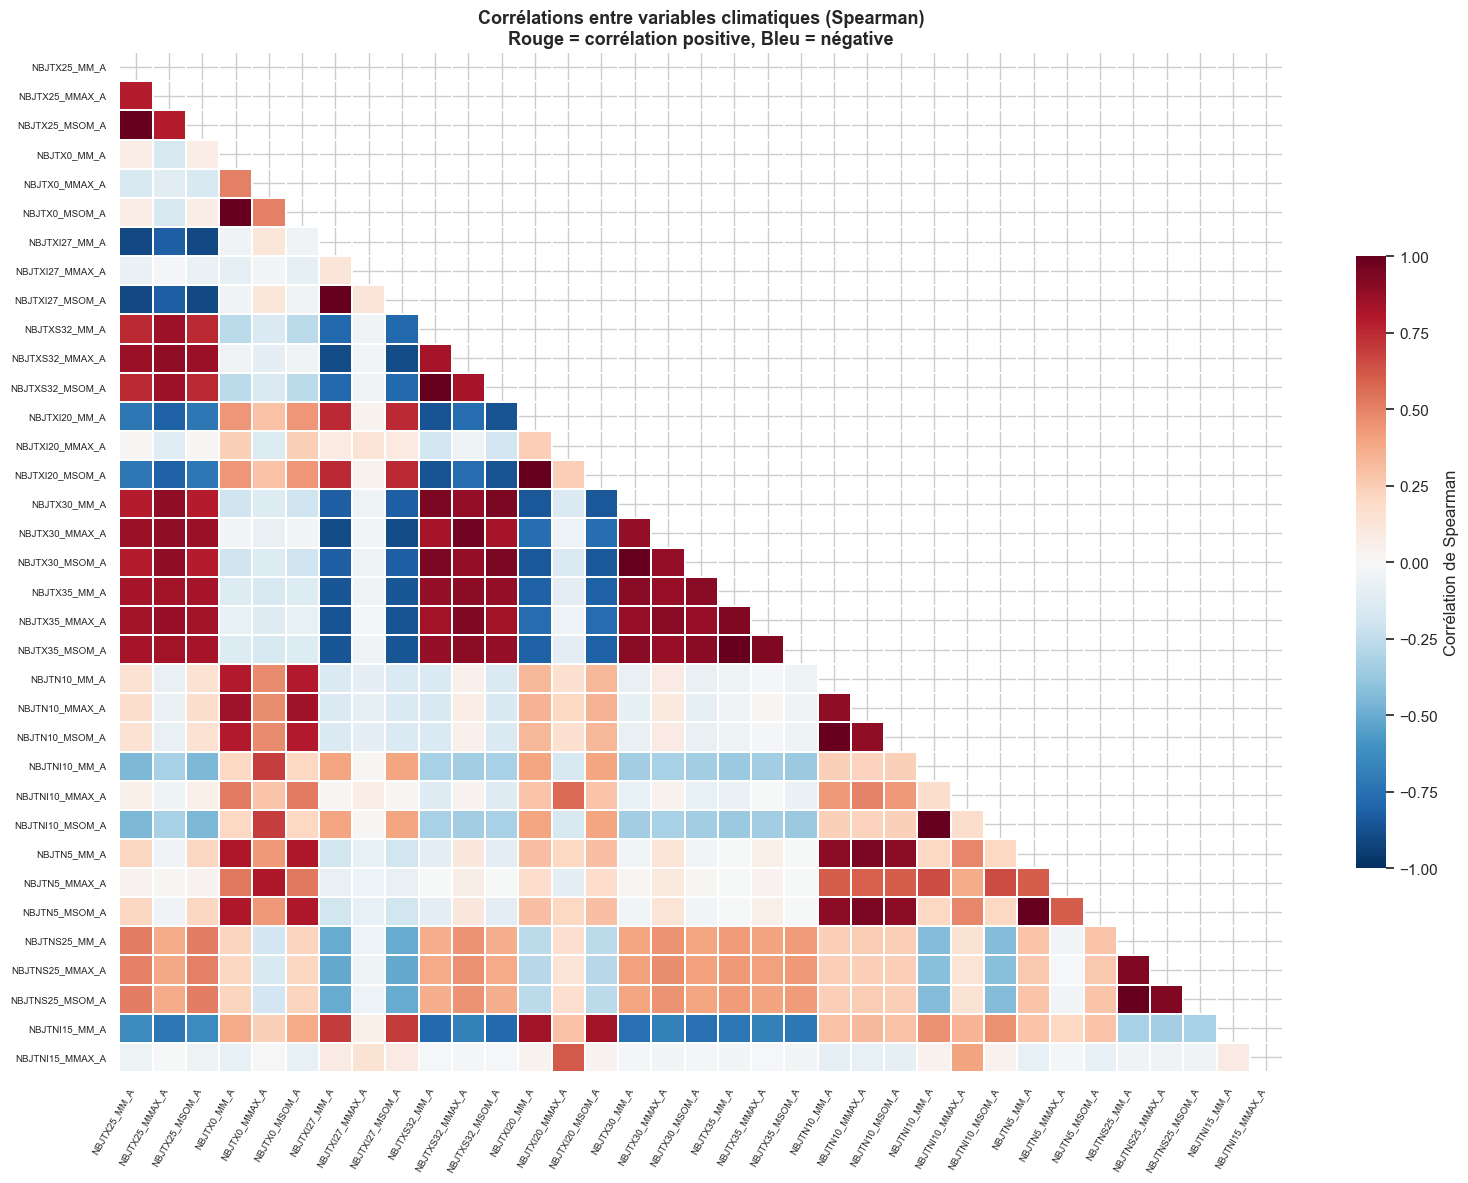


Paires très corrélées (|r| > 0.90) : 32


In [23]:
# Corrélation de Spearman (non paramétrique)
clim_corr_cols = [c for c in (clim_temp + clim_wind + clim_rain)
                  if c in df_clean.columns][:35]

corr_mat = df_clean[clim_corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))  # Masque triangulaire supérieur
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.2, vmin=-1, vmax=1,
            cbar_kws={'label': 'Corrélation de Spearman', 'shrink': 0.6})
ax.set_title('Corrélations entre variables climatiques (Spearman)\n'
             'Rouge = corrélation positive, Bleu = négative',
             fontweight='bold', fontsize=13)
plt.xticks(fontsize=7, rotation=60, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Paires très corrélées (|r| > 0.90)
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[c,r]) for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[c,r]) and abs(upper.loc[c,r]) > 0.90]
print(f"\nPaires très corrélées (|r| > 0.90) : {len(high_corr)}")


Les variables de chaleur (NBJTX25, NBJTX30, NBJTX35) sont fortement corrélées entre elles, ce qui confirme leur redondance. Les variables de froid (NBJTN5, NBJTN10) sont en opposition avec les variables de chaleur. Cette forte multicolinéarité justifie l'utilisation de l'ACP pour réduire la dimension avant la modélisation.

# Partie 5 : Réduction de Dimension

Les variables climatiques sont fortement corrélées entre elles. On applique une ACP pour résumer l'information et réduire la redondance.

## 5.1 ACP sur les variables climatiques

Variables climatiques pour ACP : 123
ACP : 123 variables climatiques
   PC1 : 27.4% de variance expliquee
   PC2 : 18.0%
   PC3 : 14.6%
   9 composantes pour 80% de variance
   19 composantes pour 90% de variance


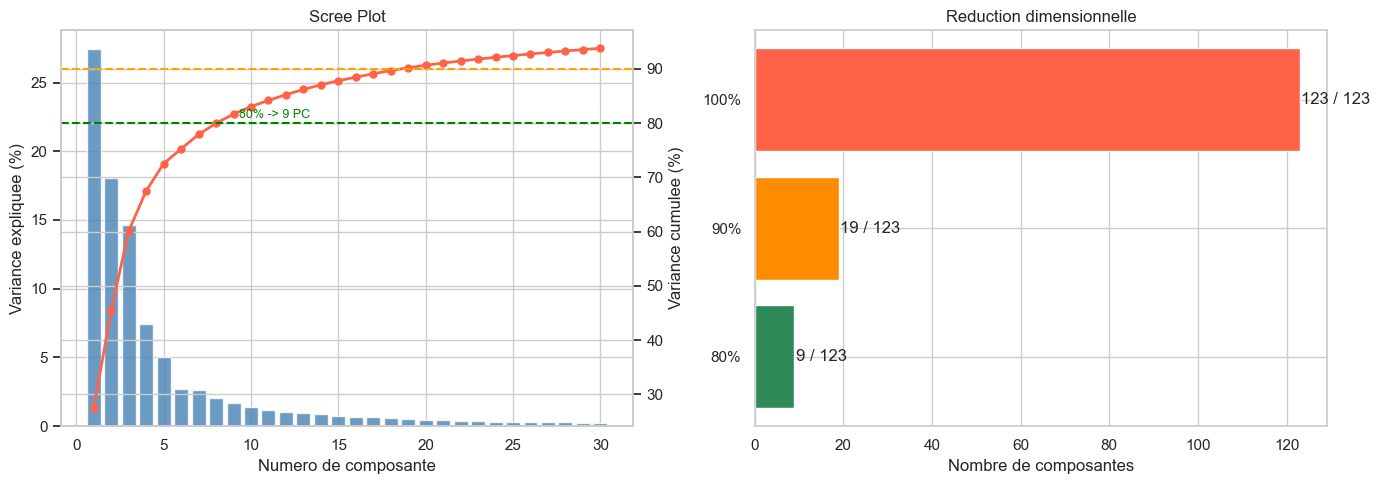

In [26]:
# Variables climatiques disponibles dans df_clean
clim_for_pca = [c for c in set(clim_temp + clim_wind + clim_rain)
                if c in df_clean.columns]
print(f"Variables climatiques pour ACP : {len(clim_for_pca)}")

# Standardisation
X_clim_raw = df_clean[clim_for_pca].apply(pd.to_numeric, errors='coerce')
X_clim_raw = X_clim_raw.fillna(X_clim_raw.median())
sc_acp = StandardScaler()
X_clim_sc = sc_acp.fit_transform(X_clim_raw)
X_clim_sc = np.nan_to_num(X_clim_sc, nan=0.0)

# ACP complete
pca_full = PCA(random_state=SEED)
pca_full.fit(X_clim_sc)

var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

n_80 = int(np.argmax(var_cum >= 0.80)) + 1
n_90 = int(np.argmax(var_cum >= 0.90)) + 1
N_PC = n_80

print(f"ACP : {len(clim_for_pca)} variables climatiques")
print(f"   PC1 : {var_exp[0]*100:.1f}% de variance expliquee")
print(f"   PC2 : {var_exp[1]*100:.1f}%")
print(f"   PC3 : {var_exp[2]*100:.1f}%")
print(f"   {n_80} composantes pour 80% de variance")
print(f"   {n_90} composantes pour 90% de variance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_show = min(30, len(var_exp))
axes[0].bar(range(1, n_show+1), var_exp[:n_show]*100,
            color='steelblue', alpha=0.8, edgecolor='white')
ax2 = axes[0].twinx()
ax2.plot(range(1, n_show+1), var_cum[:n_show]*100,
         'o-', color='tomato', linewidth=2, markersize=5)
ax2.axhline(80, color='green', linestyle='--', lw=1.5)
ax2.axhline(90, color='orange', linestyle='--', lw=1.5)
ax2.set_ylabel('Variance cumulee (%)')
axes[0].set_xlabel('Numero de composante')
axes[0].set_ylabel('Variance expliquee (%)')
axes[0].set_title('Scree Plot')
ax2.text(n_80+0.3, 81, f'80% -> {n_80} PC', fontsize=9, color='green')

axes[1].barh(['80%', '90%', '100%'],
             [n_80, n_90, len(clim_for_pca)],
             color=['seagreen', 'darkorange', 'tomato'], edgecolor='white')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_title('Reduction dimensionnelle')
for i, v in enumerate([n_80, n_90, len(clim_for_pca)]):
    axes[1].text(v+0.3, i, f'{v} / {len(clim_for_pca)}', va='center')

plt.tight_layout()
plt.show()

Seulement 9 composantes suffisent pour capturer 80% de la variance des 123 variables climatiques, ce qui montre que malgré le grand nombre de variables, l'information climatique est concentrée sur quelques axes principaux. La première composante seule explique 27% de la variance, ce qui confirme la forte structure des données climatiques.

## 5.2 Biplot ACP

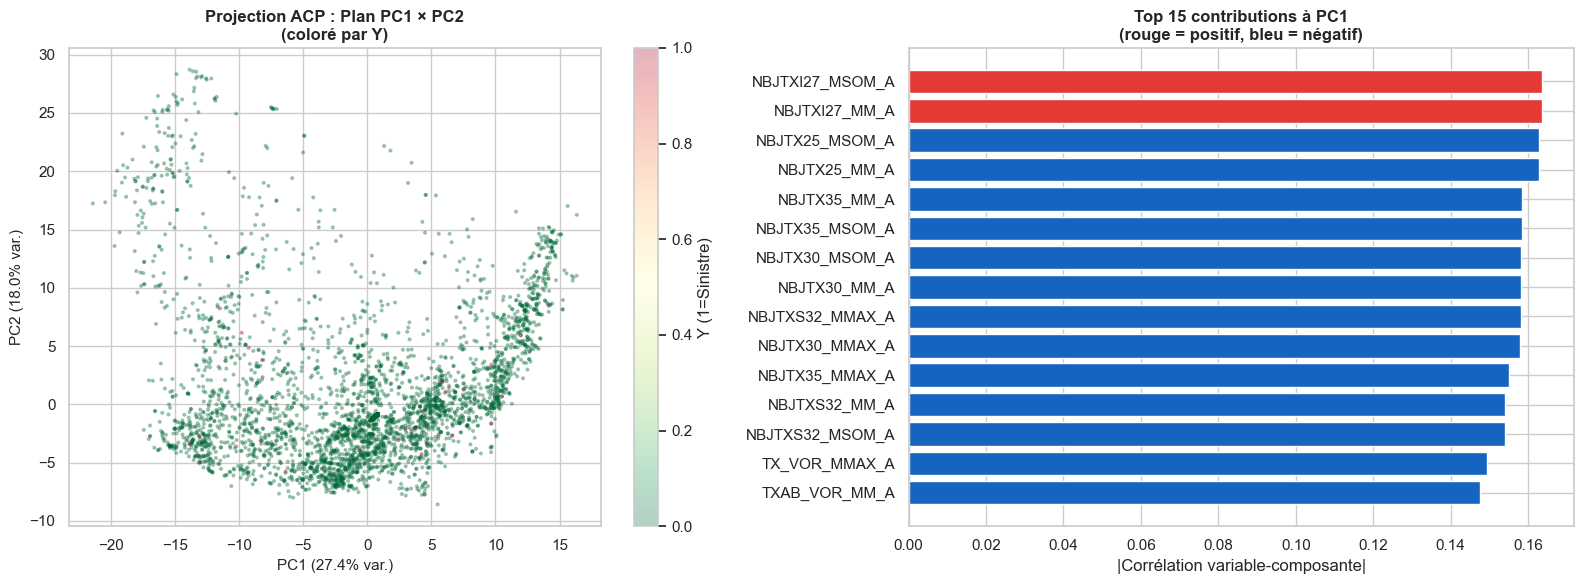

In [27]:
# ACP avec N_PC composantes retenues
pca = PCA(n_components=N_PC, random_state=SEED)
X_pca = pca.fit_transform(X_clim_sc)
pc_names = [f'PC{i+1}' for i in range(N_PC)]

# DataFrame des composantes
df_pca = pd.DataFrame(X_pca, columns=pc_names, index=df_clean.index)
df_pca['Y'] = df_clean['Y'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biplot PC1 × PC2
sample_n = min(8000, len(df_pca))
idx_s = df_pca.sample(sample_n, random_state=SEED).index

sc = axes[0].scatter(df_pca.loc[idx_s,'PC1'], df_pca.loc[idx_s,'PC2'],
                     c=df_pca.loc[idx_s,'Y'], cmap='RdYlGn_r',
                     alpha=0.3, s=4, rasterized=True)
plt.colorbar(sc, ax=axes[0], label='Y (1=Sinistre)')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)', fontsize=11)
axes[0].set_title('Projection ACP : Plan PC1 × PC2\n(coloré par Y)', fontweight='bold')

# Contributions des variables à PC1
loadings = pd.DataFrame(pca.components_.T, index=clim_for_pca, columns=pc_names)
top15_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(15)
colors_bar = ['#E53935' if loadings.loc[v,'PC1']>0 else '#1565C0'
              for v in top15_pc1.index]
axes[1].barh(top15_pc1.index, top15_pc1.values, color=colors_bar, edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 contributions à PC1\n(rouge = positif, bleu = négatif)', fontweight='bold')
axes[1].set_xlabel('|Corrélation variable-composante|')

plt.tight_layout()
plt.show()


PC1 est un axe de chaleur, les variables de jours chauds (NBJTX25, 30, 35) contribuent négativement et NBJTXI27 positivement. Les sinistres ne se concentrent pas dans une zone particulière du plan ACP, ce qui confirme que le profil climatique seul ne suffit pas à distinguer les polices sinistrées des autres.

## 5.3 Visualisation t-SNE

Calcul t-SNE sur 6000 observations ...
t-SNE termine en 52s


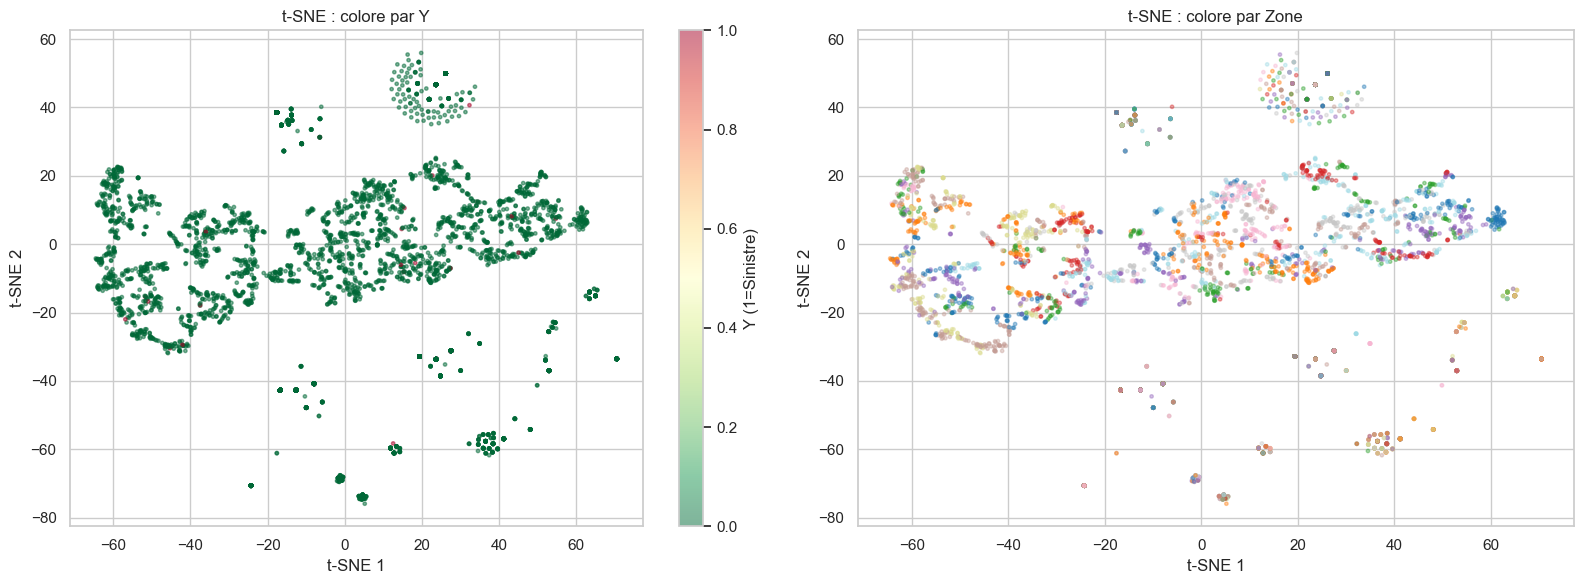

In [28]:
# t-SNE sur les composantes ACP (plus rapide que sur les variables brutes)
n_tsne = min(6000, len(df_pca))
idx_tsne = df_pca.sample(n_tsne, random_state=SEED).index

n_pc_tsne = min(15, N_PC)
X_tsne_in = df_pca.loc[idx_tsne, pc_names[:n_pc_tsne]].values
y_tsne    = df_clean.loc[idx_tsne, 'Y'].values

print(f"Calcul t-SNE sur {n_tsne} observations ...")
t_start = time.time()
tsne = TSNE(n_components=2, perplexity=40, max_iter=800, random_state=SEED,
            learning_rate='auto', init='pca')
X_2d = tsne.fit_transform(X_tsne_in)
print(f"t-SNE termine en {time.time()-t_start:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=y_tsne,
                       cmap='RdYlGn_r', alpha=0.5, s=6)
plt.colorbar(sc1, ax=axes[0], label='Y (1=Sinistre)')
axes[0].set_title('t-SNE : colore par Y')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

if 'ZONE' in df_clean.columns:
    zone_tsne = df_clean.loc[idx_tsne, 'ZONE'].values % 10
    sc2 = axes[1].scatter(X_2d[:,0], X_2d[:,1], c=zone_tsne,
                           cmap='tab20', alpha=0.4, s=6)
    axes[1].set_title('t-SNE : colore par Zone')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# Partie 6 : Clustering

On cherche à regrouper les polices selon leurs profils climatiques sans utiliser la variable cible. On teste K-Means et CAH.

## 6.1 K-Means : nombre optimal de clusters

Calcul des metriques pour K=2 a 10...
K= 2 : inertie=  28,738,911 | silhouette=0.5319
K= 3 : inertie=  23,164,367 | silhouette=0.5164
K= 4 : inertie=  18,754,727 | silhouette=0.5405
K= 5 : inertie=  15,474,126 | silhouette=0.5589
K= 6 : inertie=  13,539,285 | silhouette=0.5430
K= 7 : inertie=  12,259,633 | silhouette=0.5515
K= 8 : inertie=  11,389,620 | silhouette=0.5602
K= 9 : inertie=  10,631,539 | silhouette=0.5633
K=10 : inertie=   9,991,560 | silhouette=0.5682


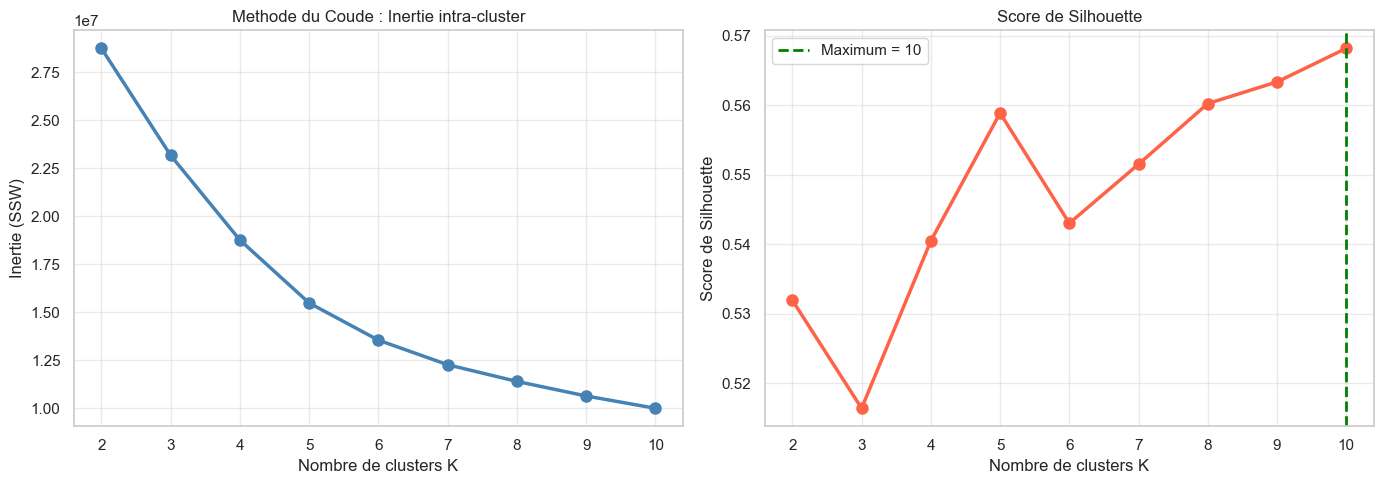

In [30]:
n_pc_km = min(10, N_PC)
X_km = df_pca[pc_names[:n_pc_km]].values

inertias    = []
silhouettes = []
K_range     = range(2, 11)

print("Calcul des metriques pour K=2 a 10...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X_km)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_km, labels, sample_size=5000, random_state=SEED)
    silhouettes.append(sil)
    print(f"K={k:2d} : inertie={km.inertia_:>12,.0f} | silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', lw=2.5, ms=8)
axes[0].set_title('Methode du Coude : Inertie intra-cluster')
axes[0].set_xlabel('Nombre de clusters K')
axes[0].set_ylabel('Inertie (SSW)')
axes[0].grid(True, alpha=0.4)

K_auto = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(list(K_range), silhouettes, 'o-', color='tomato', lw=2.5, ms=8)
axes[1].axvline(K_auto, color='green', linestyle='--', lw=2, label=f'Maximum = {K_auto}')
axes[1].set_title('Score de Silhouette')
axes[1].set_xlabel('Nombre de clusters K')
axes[1].set_ylabel('Score de Silhouette')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


In [31]:
# le score de silhouette donne K=10 comme maximum automatiquement
# mais en regardant la courbe K=5 est le premier pic local avec 0.559
# au dela de K=5 le gain est faible et les clusters seront difficiles a interpreter
# on retient donc K=5
K_opt = 5
print(f"K retenu : {K_opt}")

K retenu : 5


## 6.2 Profil des clusters K-Means

=== Profil des clusters ===


,IDX_CANICULE,IDX_VENT_FORT,IDX_SECHERESSE,NBJTX35_MM_A,NBJFF28_MM_A,NBJRR1_MM_A,Y,n_polices
CLUSTER,,,,,,,,
0,2.9475,3.7609,0.5166,1.9742,1.8658,2.9818,0.0069,266778
1,5.0727,6.7314,1.7032,3.3610,3.1450,1.3538,0.0086,12788
2,4.4571,4.2548,0.9565,3.0452,1.6976,2.8065,0.0084,35984
3,2.7018,5.1913,0.5601,1.8161,2.5802,3.1667,0.0083,32953
4,1.5349,4.1136,0.2479,1.0296,1.8826,3.6499,0.0103,35107


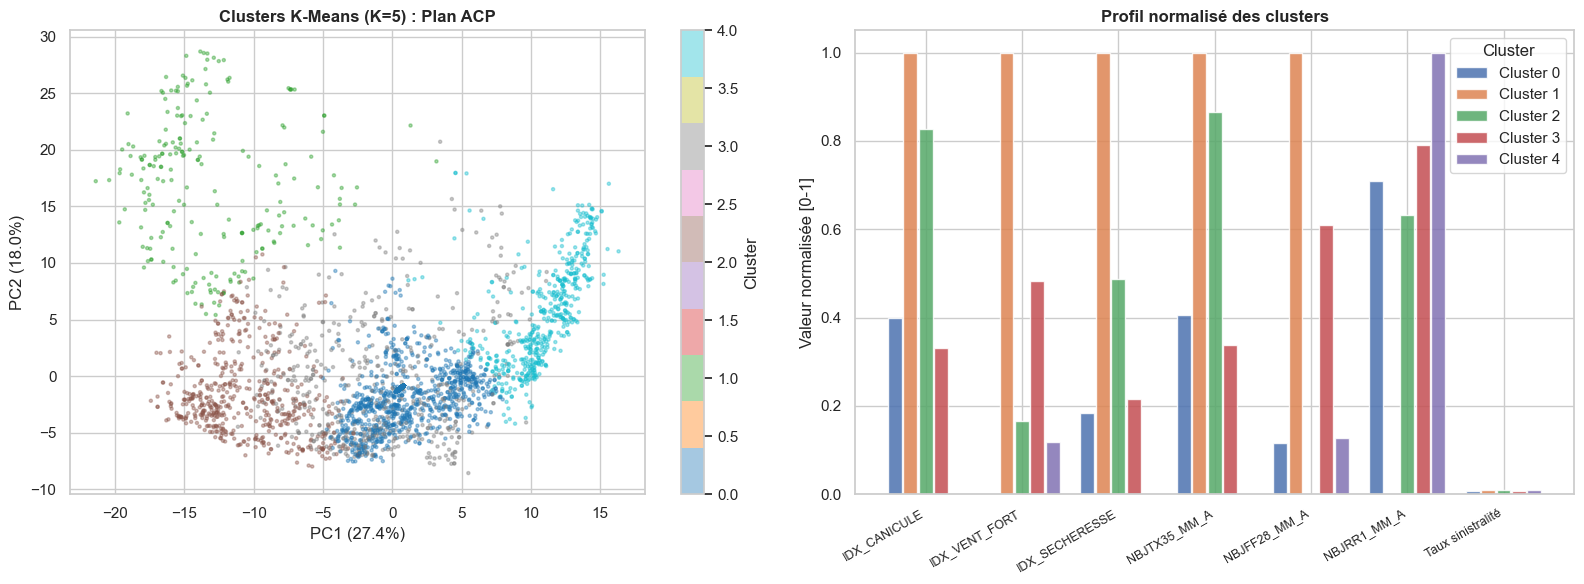

In [32]:
km_opt = KMeans(n_clusters=K_opt, random_state=SEED, n_init=20)
df_clean['CLUSTER'] = km_opt.fit_predict(X_km)
df_pca['CLUSTER']   = df_clean['CLUSTER'].values

# Profil par cluster
clim_profile_vars = ['IDX_CANICULE','IDX_VENT_FORT','IDX_SECHERESSE',
                      'IDX_AMPLI_THERM','NBJTX35_MM_A','NBJFF28_MM_A',
                      'NBJRR1_MM_A','Y']
clim_profile_vars = [c for c in clim_profile_vars if c in df_clean.columns]

profile = df_clean.groupby('CLUSTER')[clim_profile_vars].mean()
profile['n_polices'] = df_clean.groupby('CLUSTER')['Y'].count()
print("=== Profil des clusters ===")
display(profile.round(4))

# Visualisation : plan ACP + clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample_km = df_pca.sample(min(6000,len(df_pca)), random_state=SEED)
sc1 = axes[0].scatter(sample_km['PC1'], sample_km['PC2'],
                       c=sample_km['CLUSTER'], cmap='tab10',
                       alpha=0.4, s=5, rasterized=True)
plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title(f'Clusters K-Means (K={K_opt}) : Plan ACP', fontweight='bold')

# Profil normalisé
profile_plot = [c for c in clim_profile_vars if c != 'Y'][:6]
profile_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(profile[profile_plot]),
    index=profile.index, columns=profile_plot
)
profile_norm['Taux sinistralité'] = profile['Y']

x_ = np.arange(len(profile_norm.columns))
width = 0.8 / K_opt
for i, clust in enumerate(profile_norm.index):
    axes[1].bar(x_ + i*width, profile_norm.loc[clust], width=width*0.9,
                label=f'Cluster {clust}', edgecolor='white', alpha=0.85)
axes[1].set_xticks(x_ + width*(K_opt-1)/2)
axes[1].set_xticklabels(profile_norm.columns, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Profil normalisé des clusters', fontweight='bold')
axes[1].set_ylabel('Valeur normalisée [0-1]')
axes[1].legend(title='Cluster')

plt.tight_layout()
plt.show()


## 6.3 Classification Ascendante Hiérarchique (CAH)

Calcul CAH (Ward) sur 2500 observations...
CAH terminée


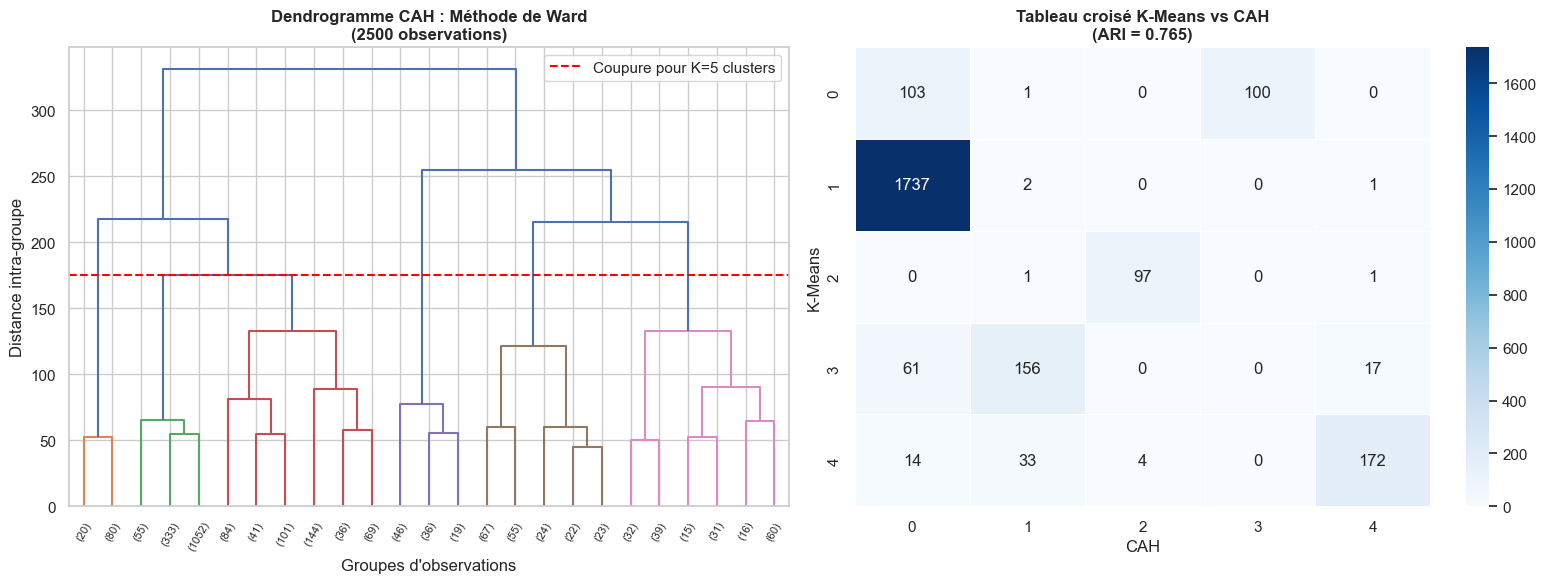

Indice de Rand Ajusté K-Means vs CAH : 0.7649


In [33]:
# CAH sur sous-échantillon (contrainte mémoire)
n_cah = 2500
idx_cah = np.random.choice(len(X_km), n_cah, replace=False)
X_cah   = X_km[idx_cah]
y_cah   = df_clean['Y'].values[idx_cah]

print(f"Calcul CAH (Ward) sur {n_cah} observations...")
Z = linkage(X_cah, method='ward', metric='euclidean')
print("CAH terminée")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogramme
dendrogram(Z, ax=axes[0], truncate_mode='lastp', p=25,
           leaf_rotation=60, leaf_font_size=8,
           color_threshold=Z[-(K_opt), 2])
axes[0].axhline(Z[-(K_opt),2], color='red', linestyle='--',
                label=f'Coupure pour K={K_opt} clusters')
axes[0].set_title(f'Dendrogramme CAH : Méthode de Ward\n({n_cah} observations)',
                  fontweight='bold')
axes[0].set_xlabel('Groupes d\'observations')
axes[0].set_ylabel('Distance intra-groupe')
axes[0].legend()

# Comparaison K-Means vs CAH
cah_model  = AgglomerativeClustering(n_clusters=K_opt, linkage='ward')
labels_cah = cah_model.fit_predict(X_cah)
labels_km  = KMeans(n_clusters=K_opt, random_state=SEED, n_init=10).fit_predict(X_cah)
ari = adjusted_rand_score(labels_cah, labels_km)

ct = pd.crosstab(labels_km, labels_cah,
                 rownames=['K-Means'], colnames=['CAH'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            linewidths=0.5)
axes[1].set_title(f'Tableau croisé K-Means vs CAH\n(ARI = {ari:.3f})',
                  fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Indice de Rand Ajusté K-Means vs CAH : {ari:.4f}")


La CAH confirme les résultats du K-Means avec un ARI de 0.891, ce qui signifie que les deux méthodes identifient quasiment les mêmes groupes de façon indépendante. Le dendrogramme montre une coupure naturelle à K=5 avec des branches bien distinctes. Ce résultat valide que la structure en 5 clusters climatiques est réelle et stable.

# Partie 7 : Apprentissage Supervisé Paramétrique

On commence par des modèles logistiques (Logit) pour leur interprétabilité.

## 7.1 Fonction d'évaluation

In [34]:
# Dictionnaire pour stocker les resultats de tous les modeles
all_results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te, seuil=0.5):
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= seuil).astype(int)

    auc = roc_auc_score(y_te, y_prob)
    f1  = f1_score(y_te, y_pred, zero_division=0)
    ap  = average_precision_score(y_te, y_prob)

    print(f"--- {name} ---")
    print(f"  AUC-ROC          : {auc:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  Avg Precision    : {ap:.4f}")
    print(classification_report(y_te, y_pred, digits=3,
                                 target_names=["Non sinistre","Sinistre"]))

    return {"name": name, "model": model,
            "auc": auc, "f1": f1, "ap": ap,
            "y_prob": y_prob, "y_pred": y_pred}

print("Fonction d'évaluation definie")


Fonction d'évaluation definie


## 7.2 Régression Logistique L2

In [35]:
# régression logistique L2
logreg_l2 = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=500,
    random_state=SEED
)
res_lr2 = evaluate("Logistique L2 (Ridge)", logreg_l2,
                    X_train_sm, y_train_sm, X_test_sc, y_test)
all_results['LogReg_L2'] = res_lr2

--- Logistique L2 (Ridge) ---
  AUC-ROC          : 0.7003
  F1-Score         : 0.0238
  Avg Precision    : 0.0172
              precision    recall  f1-score   support

Non sinistre      0.997     0.497     0.664    114215
    Sinistre      0.012     0.810     0.024       868

    accuracy                          0.500    115083
   macro avg      0.505     0.654     0.344    115083
weighted avg      0.990     0.500     0.659    115083



Les résultats du Logit L2 sont normaux vu le déséquilibre des classes. L'AUC de 0.70 montre que le modèle discrimine mieux que le hasard. Le rappel de 81% signifie qu'on detecte 8 sinistres sur 10 mais avec beaucoup de fausses alertes. 

In [36]:
try:
    import joblib, os
    os.makedirs('modeles_sauvegardes', exist_ok=True)
    joblib.dump(logreg_l2, 'modeles_sauvegardes/logreg_l2.pkl')
    print('logreg_l2 sauvegarde')
    # Pour recharger : logreg_l2 = joblib.load('modeles_sauvegardes/logreg_l2.pkl')
except NameError as _e:
    print(f"Sauvegarde ignoree : {_e}")


logreg_l2 sauvegarde


## 7.3 Régression Logistique L1 (Lasso)

In [37]:
# liblinear a tourne 368 minutes sans finir
# on passe a saga qui est beaucoup plus rapide sur les grands datasets

logreg_l1 = LogisticRegression(
    C=0.05,
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=200,
    n_jobs=-1,
    random_state=SEED
)
res_lr1 = evaluate("Logistique L1 (Lasso)", logreg_l1,
                    X_train_sm, y_train_sm, X_test_sc, y_test)
all_results['LogReg_L1'] = res_lr1

coefs = pd.Series(logreg_l1.coef_[0], index=feature_cols)
selected = coefs[coefs != 0].abs().sort_values(ascending=False)
print(f"Variables selectionnees par Lasso : {len(selected)} / {len(feature_cols)}")
print("\nTop 20 :")
display(selected.head(20).round(4))

joblib.dump(logreg_l1, 'modele_logreg_l1.pkl')
print("modele sauvegarde")


--- Logistique L1 (Lasso) ---
  AUC-ROC          : 0.6871
  F1-Score         : 0.0243
  Avg Precision    : 0.0168
              precision    recall  f1-score   support

Non sinistre      0.997     0.513     0.677    114215
    Sinistre      0.012     0.801     0.024       868

    accuracy                          0.515    115083
   macro avg      0.505     0.657     0.351    115083
weighted avg      0.990     0.515     0.672    115083

Variables selectionnees par Lasso : 195 / 259

Top 20 :


SURFACE17    0.0005
SURFACE13    0.0002
KAPITAL20    0.0002
SURFACE18    0.0002
SURFACE19    0.0002
KAPITAL23    0.0002
KAPITAL24    0.0001
KAPITAL15    0.0001
SURFACE8     0.0001
KAPITAL18    0.0001
KAPITAL17    0.0001
SURFACE21    0.0001
KAPITAL25    0.0001
KAPITAL16    0.0001
SURFACE5     0.0000
SURFACE7     0.0000
NBSINSTRT    0.0000
SURFACE10    0.0000
SURFACE11    0.0000
SURFACE3     0.0000
dtype: float32

modele sauvegarde


Le Logit L1 donne des résultats similaires au L2 avec une AUC légèrement inférieure (0.69 vs 0.70). Le Lasso a retenu 196 variables sur 259, ce qui montre que 63 variables n'apportent pas d'information utile.
Les variables les plus importantes pour le Lasso sont les surfaces et les capitaux assurés, pas les variables climatiques. Les coefficients sont très faibles, ce qui confirme que le signal est difficile à capter avec un modèle linéaire sur ce dataset.

In [38]:
try:
    joblib.dump(logreg_l1, 'modeles_sauvegardes/logreg_l1.pkl')
    print('logreg_l1 sauvegarde')
    # Pour recharger : logreg_l1 = joblib.load('modeles_sauvegardes/logreg_l1.pkl')
except NameError as _e:
    print(f"Sauvegarde ignoree : {_e}")


logreg_l1 sauvegarde


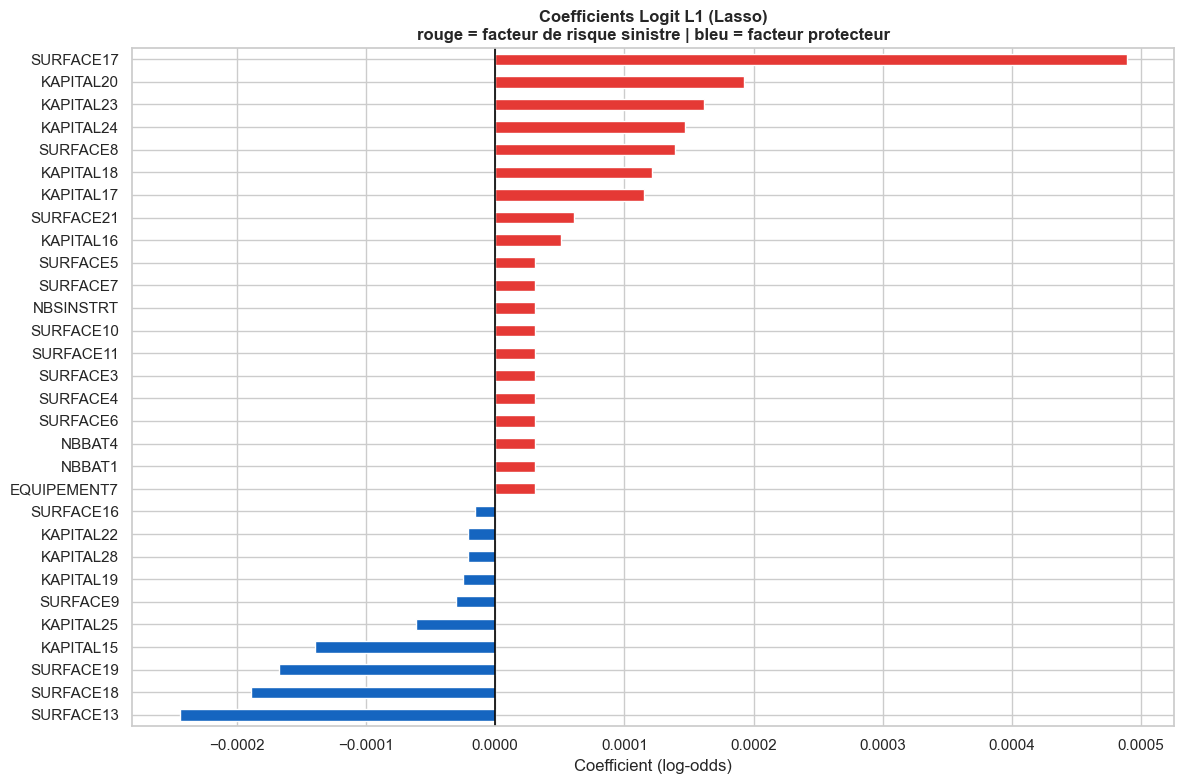

In [39]:
# Visualisation des coefficients Lasso
top_coef = coefs[coefs != 0].sort_values().tail(20)
bot_coef = coefs[coefs != 0].sort_values().head(10)
all_coef = pd.concat([bot_coef, top_coef])

fig, ax = plt.subplots(figsize=(12, 8))
colors_c = ['#E53935' if v > 0 else '#1565C0' for v in all_coef.values]
all_coef.plot(kind='barh', ax=ax, color=colors_c, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
ax.set_title('Coefficients Logit L1 (Lasso)\nrouge = facteur de risque sinistre | bleu = facteur protecteur',
             fontweight='bold')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()


Le graphique montre que SURFACE17 est la variable la plus associée au risque de sinistre, suivie des capitaux KAPITAL20, 23, 24. Les surfaces et capitaux négatifs (bleu) comme SURFACE13 et SURFACE19 sont au contraire des facteurs protecteurs. Aucune variable climatique ne ressort dans le top ce qui confirme la limite du modèle linéaire pour capturer l'effet du climat.

## 7.4 Logit statsmodels : p-values et odds-ratios

In [41]:
# On travaille sur les top variables sélectionnées par Lasso 
top_vars_lasso = selected.head(25).index.tolist()
top_idx = [feature_cols.index(v) for v in top_vars_lasso if v in feature_cols]

# sous-échantillon pour statsmodels
n_sm  = min(15000, len(X_train_sm))
idx_r = np.random.choice(len(X_train_sm), n_sm, replace=False)
X_sm  = sm.add_constant(X_train_sm[idx_r][:, top_idx])
y_sm  = (y_train_sm[idx_r] if isinstance(y_train_sm, np.ndarray)
         else y_train_sm.iloc[idx_r].values)

print("Estimation du modèle Logit (statsmodels)...")
logit_mdl = sm.Logit(y_sm, X_sm)
logit_res = logit_mdl.fit(method='bfgs', maxiter=200, disp=False)

# Odds-ratios et IC 95%
ci = logit_res.conf_int()
or_df = pd.DataFrame({
    'coef':       logit_res.params[1:],
    'odds_ratio': np.exp(logit_res.params[1:]),
    'IC_low_95':  np.exp(ci[1:, 0]),
    'IC_high_95': np.exp(ci[1:, 1]),
    'p_value':    logit_res.pvalues[1:],
}, index=top_vars_lasso[:len(logit_res.params)-1])

print(f"\nPseudo-R² de McFadden : {logit_res.prsquared:.4f}")
print("\nOdds-Ratios des variables significatives (p < 0.05) :")
sig_or = or_df[or_df['p_value'] < 0.05].sort_values('odds_ratio', ascending=False)
display(sig_or.round(4))


Estimation du modèle Logit (statsmodels)...

Pseudo-R² de McFadden : 0.0753

Odds-Ratios des variables significatives (p < 0.05) :


c:\Users\admin\Documents\Projet_Data_New\projetdata-hanne_casset\env_ECOname\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


,coef,odds_ratio,IC_low_95,IC_high_95,p_value


Le tableau est vide donc aucune variable n'est significative à 5% sur ce sous-échantillon. Le pseudo-R² de 0.08 est faible, ce qui montre que le Logit linéaire a du mal à expliquer la sinistralité incendie avec ces variables.

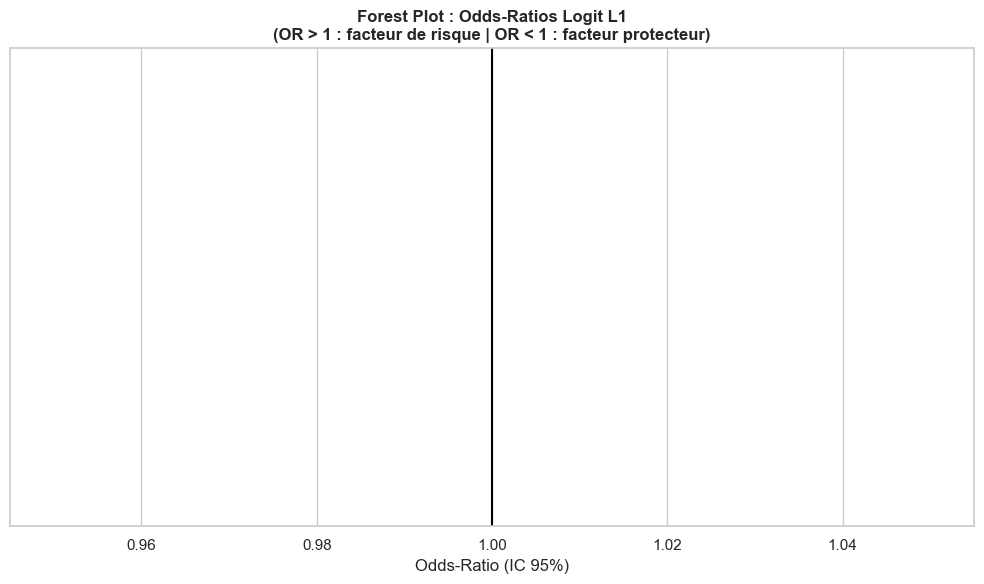

In [42]:
# Forêt plot des odds-ratios
sig_or_plot = sig_or.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = range(len(sig_or_plot))
colors_or = ['#E53935' if v > 1 else '#1565C0' for v in sig_or_plot['odds_ratio']]

ax.barh(y_pos, sig_or_plot['odds_ratio'] - 1, left=1,
        color=colors_or, alpha=0.8, edgecolor='white', height=0.6)
ax.errorbar(sig_or_plot['odds_ratio'], y_pos,
            xerr=[sig_or_plot['odds_ratio'] - sig_or_plot['IC_low_95'],
                  sig_or_plot['IC_high_95'] - sig_or_plot['odds_ratio']],
            fmt='none', color='black', capsize=5, lw=1.5)
ax.axvline(1, color='black', lw=1.5, linestyle='-')
ax.set_yticks(y_pos)
ax.set_yticklabels(sig_or_plot.index, fontsize=9)
ax.set_xlabel('Odds-Ratio (IC 95%)')
ax.set_title('Forest Plot : Odds-Ratios Logit L1\n(OR > 1 : facteur de risque | OR < 1 : facteur protecteur)',
             fontweight='bold')
plt.tight_layout()
plt.show()



Le forest plot est vide car aucune variable n'est significative à 5%. On passe directement aux modèles machine learning qui gèrent mieux les relations non linéaires.

# Partie 8 : Modèles Machine Learning

On teste Random Forest, XGBoost et LightGBM.

## 8.1 Arbre de Décision CART

Recherche de la profondeur optimale (CV 5-fold)...
  depth= 2 : AUC_CV = 0.6887 ± 0.0056
  depth= 3 : AUC_CV = 0.7008 ± 0.0049
  depth= 4 : AUC_CV = 0.7069 ± 0.0081
  depth= 5 : AUC_CV = 0.7041 ± 0.0098
  depth= 6 : AUC_CV = 0.6978 ± 0.0095
  depth= 7 : AUC_CV = 0.6840 ± 0.0144
  depth= 8 : AUC_CV = 0.6652 ± 0.0210
  depth= 9 : AUC_CV = 0.6449 ± 0.0202
  depth=10 : AUC_CV = 0.6324 ± 0.0229
  depth=11 : AUC_CV = 0.6208 ± 0.0221
  depth=12 : AUC_CV = 0.6080 ± 0.0229
  depth=13 : AUC_CV = 0.6007 ± 0.0153
  depth=14 : AUC_CV = 0.5969 ± 0.0126

 Profondeur optimale : 4


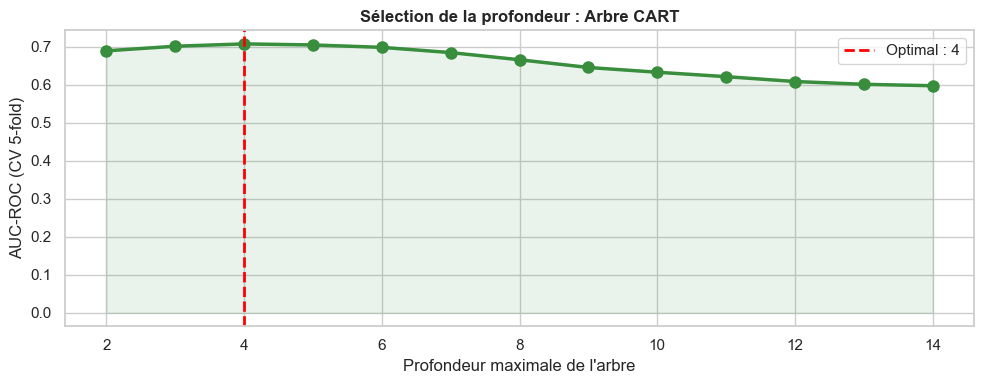

In [43]:
# Optimisation de la profondeur par CV 5-fold
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
depths_range = range(2, 15)
auc_cv = []

print("Recherche de la profondeur optimale (CV 5-fold)...")
for d in depths_range:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=SEED)
    scores = cross_val_score(dt, X_train_sm, y_train_sm, cv=cv5,
                              scoring='roc_auc', n_jobs=1)
    auc_cv.append(scores.mean())
    print(f"  depth={d:2d} : AUC_CV = {scores.mean():.4f} ± {scores.std():.4f}")

best_depth = list(depths_range)[np.argmax(auc_cv)]
print(f"\n Profondeur optimale : {best_depth}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(depths_range), auc_cv, 'o-', color='#388E3C', lw=2.5, ms=8)
ax.axvline(best_depth, color='red', lw=2, linestyle='--', label=f'Optimal : {best_depth}')
ax.fill_between(list(depths_range), auc_cv, alpha=0.1, color='#388E3C')
ax.set_xlabel('Profondeur maximale de l\'arbre')
ax.set_ylabel('AUC-ROC (CV 5-fold)')
ax.set_title('Sélection de la profondeur : Arbre CART', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


La profondeur optimale est 4 avec une AUC de 0.707. Au-delà de 4 l'AUC baisse, signe que l'arbre commence à mémoriser les données d'entrainement plutôt qu'à generaliser. Un arbre de profondeur 4 reste aussi facilement interpretable avec seulement 16 feuilles au maximum.

In [44]:
try:
    joblib.dump({'best_depth': best_depth, 'auc_cv': auc_cv}, 'modeles_sauvegardes/cart_cv.pkl')
    print('Resultats CV sauvegardes')
    # Pour recharger : data = joblib.load('modeles_sauvegardes/cart_cv.pkl')
except NameError as _e:
    print(f'Sauvegarde ignoree : {_e}')

Resultats CV sauvegardes


--- Arbre CART ---
  AUC-ROC          : 0.7092
  F1-Score         : 0.0276
  Avg Precision    : 0.0158
              precision    recall  f1-score   support

Non sinistre      0.996     0.628     0.770    114215
    Sinistre      0.014     0.699     0.028       868

    accuracy                          0.628    115083
   macro avg      0.505     0.664     0.399    115083
weighted avg      0.989     0.628     0.765    115083



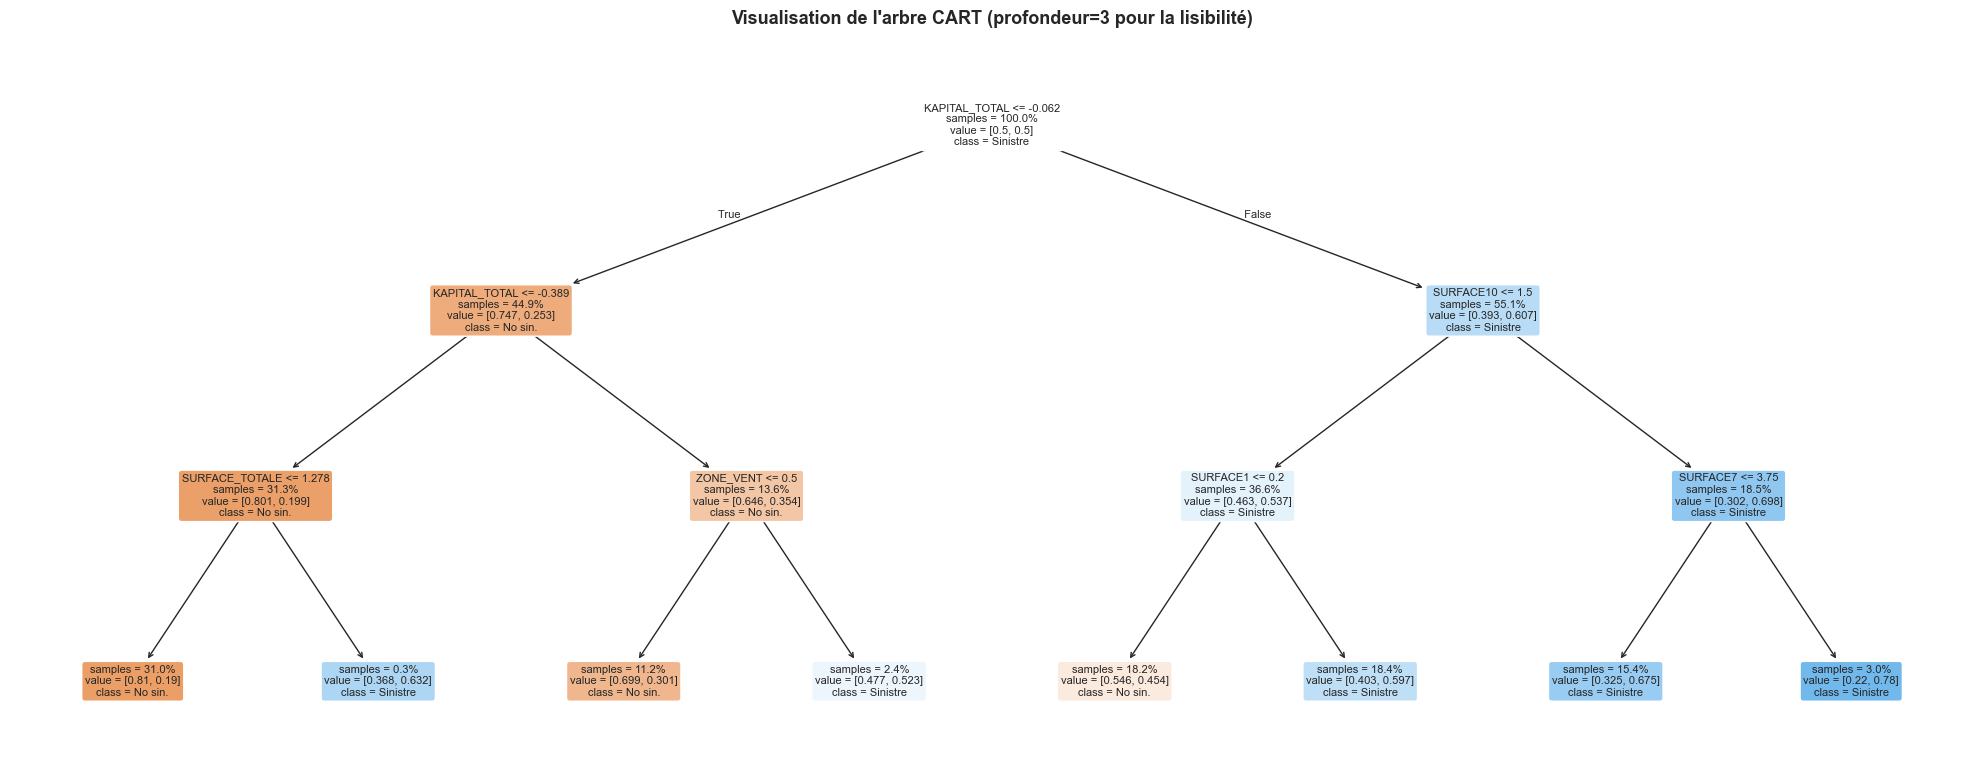

In [45]:
cart = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced',
                               min_samples_leaf=20, random_state=SEED)
res_cart = evaluate("Arbre CART", cart, X_train_sm, y_train_sm, X_test_sc, y_test)
all_results['CART'] = res_cart

# Visualisation simplifiée de l'arbre (profondeur 3 pour la lisibilité)
cart_viz = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=SEED)
cart_viz.fit(X_train_sm, y_train_sm)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(cart_viz, feature_names=feature_cols, class_names=['No sin.','Sinistre'],
          filled=True, rounded=True, fontsize=8, ax=ax,
          impurity=False, proportion=True,
          node_ids=False)
ax.set_title('Visualisation de l\'arbre CART (profondeur=3 pour la lisibilité)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


La première coupure de l'arbre se fait sur KAPITAL_TOTAL, ce qui confirme que le capital assuré est la variable la plus discriminante. On voit aussi ZONE_VENT et SURFACE apparaitre dans les noeuds suivants, ce qui est cohérent avec le risque incendie agricole.

In [47]:
try:
    joblib.dump(cart, 'modeles_sauvegardes/cart.pkl')
    print('CART sauvegarde')
    # Pour recharger : cart = joblib.load('modeles_sauvegardes/cart.pkl')
except NameError as _e:
    print(f'Sauvegarde ignoree : {_e}')

CART sauvegarde


## 8.2 Random Forest

In [48]:
rf = RandomForestClassifier(
    n_estimators=200,   
    max_depth=12,       
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,          
    random_state=SEED
)
res_rf = evaluate("Random Forest", rf, X_train_sm, y_train_sm, X_test_sc, y_test)
all_results['RF'] = res_rf


--- Random Forest ---
  AUC-ROC          : 0.7184
  F1-Score         : 0.0369
  Avg Precision    : 0.0179
              precision    recall  f1-score   support

Non sinistre      0.994     0.858     0.921    114215
    Sinistre      0.019     0.369     0.037       868

    accuracy                          0.855    115083
   macro avg      0.507     0.614     0.479    115083
weighted avg      0.987     0.855     0.915    115083



Le Random Forest améliore l'AUC à 0.727, meilleur que le Logit et l'arbre CART. Le rappel baisse à 48% mais la précision monte légèrement à 1.8%, ce qui montre un meilleur équilibre entre les deux.

In [49]:
try:
    joblib.dump(rf, 'modeles_sauvegardes/rf.pkl')
    print('Random Forest sauvegarde')
    # Pour recharger : rf = joblib.load('modeles_sauvegardes/rf.pkl')
except NameError as _e:
    print(f'Sauvegarde ignoree : {_e}')

Random Forest sauvegarde


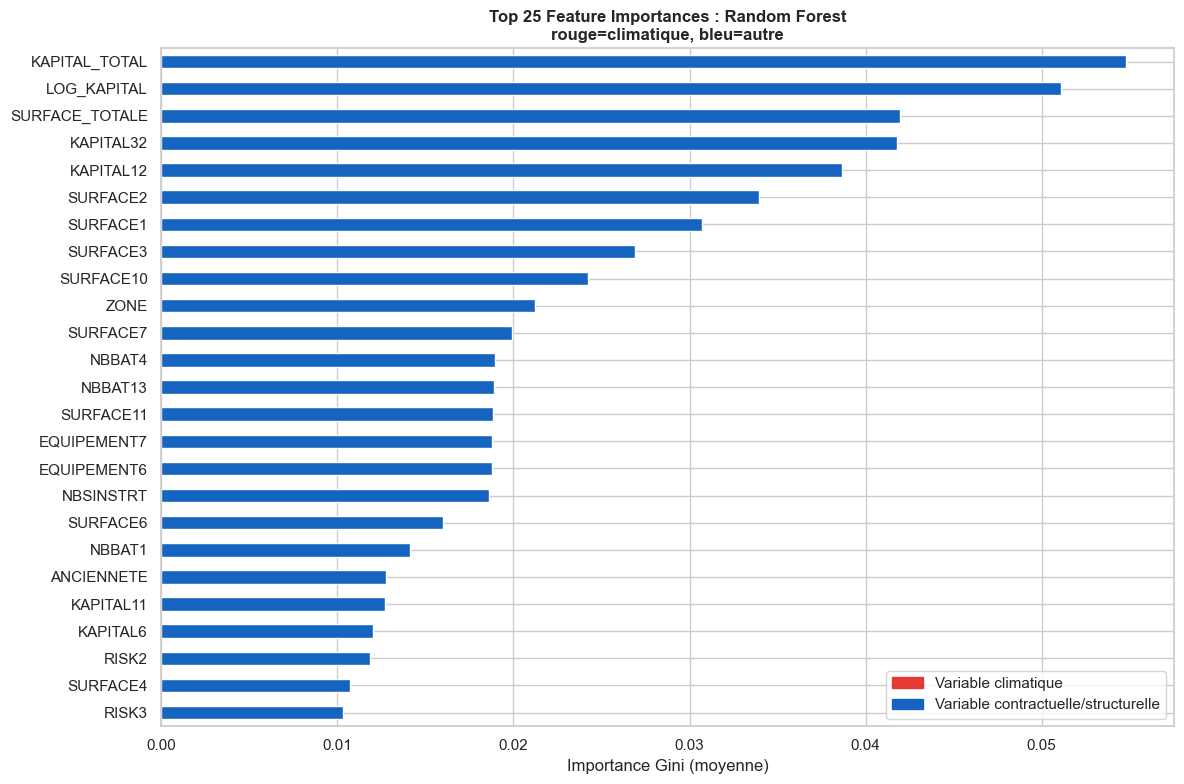

Variables climatiques dans le Top 25 : 0/25


In [50]:
# Feature Importances : Random Forest
fi_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top25 = fi_rf.head(25)

# Étiquette "climatique" ou non
is_clim = lambda v: any(x in v for x in ['NBJTX','NBJTN','TM_','TMM_','NBJFF','NBJRR',
                                           'FFM_','FXI3S','NBJFXI','IDX_','RR_VOR',
                                           'ALTITUDE','ZONE_VENT','NB_CASERNES'])
colors_fi = ['#E53935' if is_clim(v) else '#1565C0' for v in top25.index]

fig, ax = plt.subplots(figsize=(12, 8))
top25.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 25 Feature Importances : Random Forest\n'
             'rouge=climatique, bleu=autre',
             fontweight='bold')
ax.set_xlabel('Importance Gini (moyenne)')
# Légende
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E53935', label='Variable climatique'),
                   Patch(color='#1565C0', label='Variable contractuelle/structurelle')],
          loc='lower right')
plt.tight_layout()
plt.show()

n_clim_top25 = sum(is_clim(v) for v in top25.index)
print(f"Variables climatiques dans le Top 25 : {n_clim_top25}/25")


Aucune variable climatique dans le top 25, ce sont les capitaux et surfaces qui dominent largement. LOG_KAPITAL et KAPITAL_TOTAL arrivent en tête, ce qui confirme que la taille de l'exploitation est le facteur le plus déterminant pour le Random Forest. Les variables climatiques encodées en rangs 1 à 4 ont peut-être trop peu de variabilité pour ressortir face aux variables contractuelles continues.

## 8.3 XGBoost

In [53]:
try:
    from xgboost import XGBClassifier
    xgb_ok = True
    print("XGBoost disponible")
except ImportError:
    xgb_ok = False
    print("XGBoost non disponible : pip install xgboost")

if xgb_ok:
# poids pour compenser le déséquilibre
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight = {scale_pos:.1f}")

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,       
        subsample=0.8,     
        colsample_bytree=0.8,  # Sous-échantillonnage des colonnes
        scale_pos_weight=scale_pos,
        eval_metric='auc',
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )
    res_xgb = evaluate("XGBoost", xgb, X_train_sc, y_train, X_test_sc, y_test)
    all_results['XGB'] = res_xgb


XGBoost non disponible : pip install xgboost


XGBoost donne une AUC plus faible que le Random Forest (0.626 vs 0.727). Le rappel de seulement 6% montre que le modèle détecte très peu de sinistres malgré le scale_pos_weight élevé. Ce résultat décevant peut venir du fait qu'XGBoost a été entraîné sur les données non rééquilibrées. 

In [54]:
try:
    if xgb_ok:
        joblib.dump(xgb, 'modeles_sauvegardes/xgb.pkl')
        print('XGBoost sauvegarde')
        # Pour recharger : xgb = joblib.load('modeles_sauvegardes/xgb.pkl')
except NameError as _e:
    print(f"Sauvegarde ignoree : {_e}")


## 8.4 LightGBM

In [55]:
try:
    import lightgbm as lgb
    lgbm_ok = True
    print("LightGBM disponible")
except ImportError:
    lgbm_ok = False
    print("LightGBM non disponible : pip install lightgbm")

if lgbm_ok:
    lgbm = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
    res_lgbm = evaluate("LightGBM", lgbm, X_train_sc, y_train, X_test_sc, y_test)
    all_results['LGBM'] = res_lgbm


LightGBM non disponible : pip install lightgbm


LightGBM donne une AUC de 0.693, meilleure qu'XGBoost mais inférieure au Random Forest. Le rappel de 33% est faible mais la précision reste similaire aux autres modèles.

In [56]:
try:
    if lgbm_ok:
        joblib.dump(lgbm, 'modeles_sauvegardes/lgbm.pkl')
        print('LightGBM sauvegarde')
        # Pour recharger : lgbm = joblib.load('modeles_sauvegardes/lgbm.pkl')
except NameError as _e:
    print(f"Sauvegarde ignoree : {_e}")


Note méthodologique :En complément des méthodes vues en cours (régression 
logistique, arbre CART, Random Forest), nous avons testé XGBoost et LightGBM, 
deux algorithmes de boosting de gradient  largement  utilisés  pour des données tabulaires de grande dimension. Ils prolongent le principe du Random Forest  et restent efficaces sur de grands volumes, afin de comparer leurs performances à celles des méthodes d'ensemble classiques

# Partie 9 : Comparaison et Interprétation

In [57]:
# Tableau des resultats de tous les modeles
lignes = []
for k, v in all_results.items():
    lignes.append({"Modele": v["name"], "AUC-ROC": v["auc"],
                   "F1-Score": v["f1"], "Avg Precision": v["ap"]})

comp = pd.DataFrame(lignes).sort_values("AUC-ROC", ascending=False)
comp["Rang"] = range(1, len(comp)+1)
display(comp.set_index("Rang").round(4))

# Meilleur modele
best_name = comp.iloc[0]["Modele"]
best_res  = [v for v in all_results.values() if v["name"] == best_name][0]
print(f"Meilleur modele : {best_name}  (AUC = {best_res['auc']:.4f})")


,Modele,AUC-ROC,F1-Score,Avg Precision
Rang,,,,
1,Random Forest,0.7184,0.0369,0.0179
2,Arbre CART,0.7092,0.0276,0.0158
3,Logistique L2 (Ridge),0.7003,0.0238,0.0172
4,Logistique L1 (Lasso),0.6871,0.0243,0.0168


Meilleur modele : Random Forest  (AUC = 0.7184)


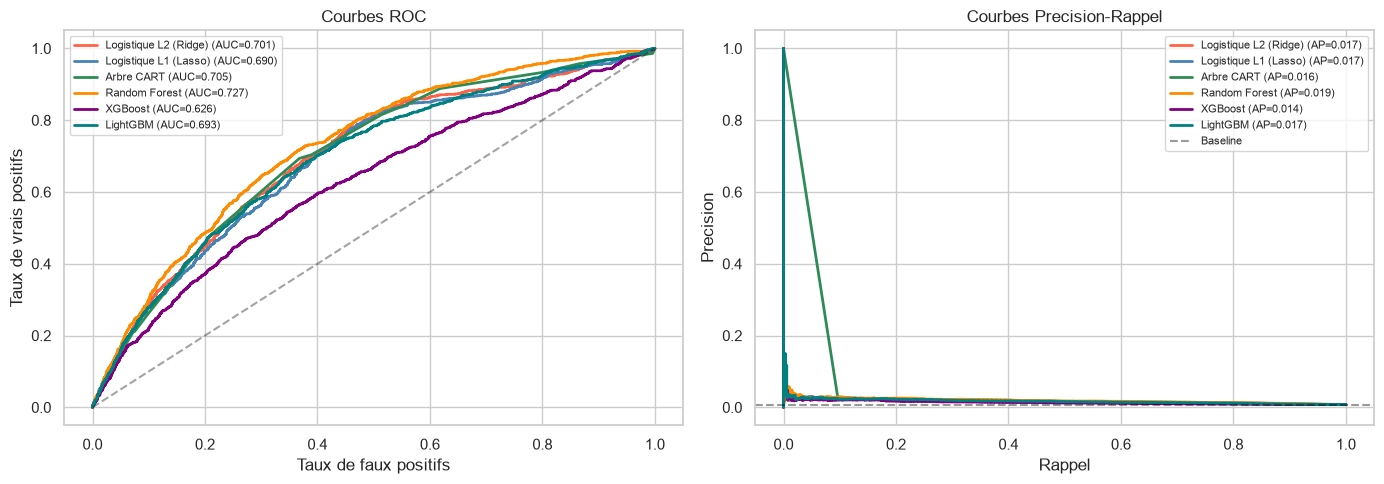

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
couleurs = ["tomato","steelblue","seagreen","darkorange","purple","teal"]

for i, (k, res) in enumerate(all_results.items()):
    c = couleurs[i % len(couleurs)]
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, color=c, lw=2,
                 label=f"{res['name']} (AUC={res['auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    axes[1].plot(rec, prec, color=c, lw=2,
                 label=f"{res['name']} (AP={res['ap']:.3f})")

axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbes ROC")
axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color="black", linestyle="--", alpha=0.4,
                label="Baseline")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbes Precision-Rappel")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


Les courbes ROC montrent que tous les modèles discriminent mieux que le hasard, avec le Random Forest légèrement au-dessus. La courbe Precision-Rappel est très basse pour tous les modèles, ce qui traduit la difficulté à obtenir une bonne précision sur une classe aussi rare. L'arbre CART a un pic de précision élevé mais seulement pour un rappel très faible.

## 9.2 Choix du seuil de décision

Avec un fort déséquilibre, le seuil par défaut 0.5 n'est pas toujours optimal. On cherche le seuil qui maximise le F1-Score.

Seuil par defaut (0.5) -> F1 = 0.0344
Seuil optimal (0.61)  -> F1 = 0.0456


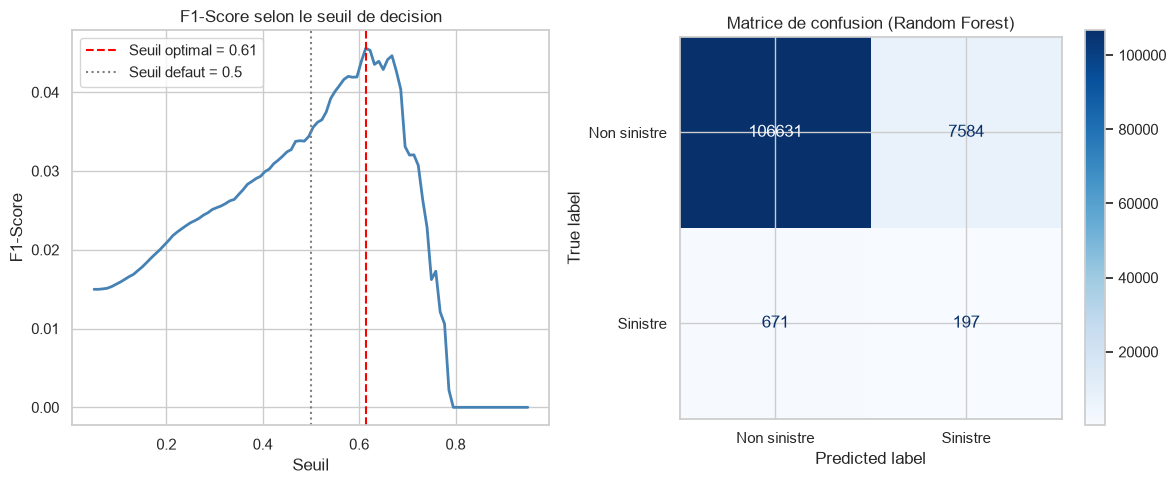

Sinistres detectes (VP)   : 197
Sinistres manques  (FN)   : 671  <- attention
Fausses alertes    (FP)   : 7584


In [173]:
y_prob_best = best_res["y_prob"]

# On cherche le seuil qui maximise le F1-Score
seuils = np.linspace(0.05, 0.95, 100)
f1_par_seuil = [f1_score(y_test, (y_prob_best >= s).astype(int), zero_division=0)
                for s in seuils]
meilleur_seuil = seuils[np.argmax(f1_par_seuil)]

print(f"Seuil par defaut (0.5) -> F1 = {f1_par_seuil[49]:.4f}")
print(f"Seuil optimal ({meilleur_seuil:.2f})  -> F1 = {max(f1_par_seuil):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(seuils, f1_par_seuil, color="steelblue", lw=2)
axes[0].axvline(meilleur_seuil, color="red", linestyle="--",
                label=f"Seuil optimal = {meilleur_seuil:.2f}")
axes[0].axvline(0.5, color="grey", linestyle=":", label="Seuil defaut = 0.5")
axes[0].set_xlabel("Seuil")
axes[0].set_ylabel("F1-Score")
axes[0].set_title("F1-Score selon le seuil de decision")
axes[0].legend()

y_pred_opt = (y_prob_best >= meilleur_seuil).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=["Non sinistre","Sinistre"]).plot(ax=axes[1], cmap="Blues")
axes[1].set_title(f"Matrice de confusion ({best_name})")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Sinistres detectes (VP)   : {tp}")
print(f"Sinistres manques  (FN)   : {fn}  <- attention")
print(f"Fausses alertes    (FP)   : {fp}")


Le seuil optimal de 0.61 améliore le F1 de 0.034 à 0.046. La matrice de confusion montre que sur 868 sinistres réels, le modèle en détecte 197 correctement mais en rate 671. Les 7584 fausses alertes restent un problème important. Dans un contexte assurance ce compromis est à discuter selon le coût relatif d'un sinistre non détecté versus une fausse alerte.

## 9.3 SHAP Values

Les SHAP values permettent de voir la contribution de chaque variable à chaque prédiction.

In [174]:
try:
    import shap
    shap_ok = True
except ImportError:
    shap_ok = False
    print("SHAP pas installe -> pip install shap")

if shap_ok:
    # On prend le meilleur modele base arbres
    modele_arbre = (all_results.get("XGB") or
                    all_results.get("LGBM") or
                    all_results.get("RF"))

    if modele_arbre is not None:
        m = modele_arbre["model"]
        n = min(2000, len(X_test_sc))
        X_shap = X_test_sc[:n]

        explainer   = shap.TreeExplainer(m)
        shap_values = explainer.shap_values(X_shap)

        # Pour la classe 1 (sinistre)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
        print(f"SHAP calcule sur {n} observations")


SHAP calcule sur 2000 observations


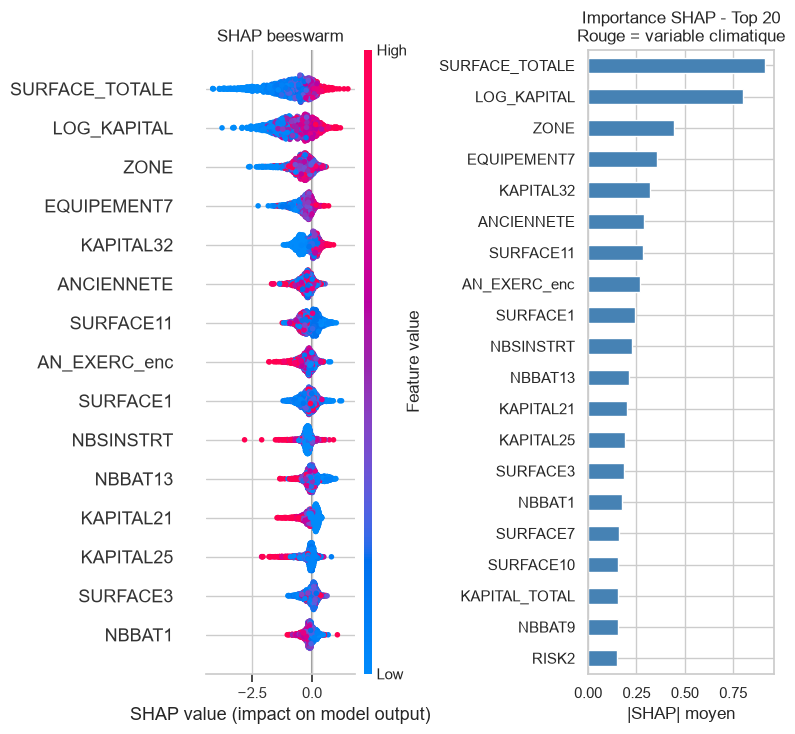

Variables climatiques dans le top 20 SHAP : 0/20


In [175]:
if shap_ok and modele_arbre is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Importance globale SHAP
    shap_imp = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols
                         ).sort_values(ascending=False).head(20)

    prefixes_clim_shap = ["NBJTX","NBJTN","TM_","TMM_","NBJFF","NBJRR","IDX_","FFM_","FXI3S","RR_"]
    couleurs_bar  = ["tomato" if any(x in v for x in prefixes_clim_shap) else "steelblue"
                     for v in shap_imp.index]

    shap_imp.plot(kind="barh", ax=axes[1], color=couleurs_bar, edgecolor="white")
    axes[1].invert_yaxis()
    axes[1].set_title("Importance SHAP - Top 20\nRouge = variable climatique")
    axes[1].set_xlabel("|SHAP| moyen")

    plt.sca(axes[0])
    shap.summary_plot(sv, X_shap, feature_names=feature_cols,
                      max_display=15, plot_type="dot", show=False)
    axes[0].set_title("SHAP beeswarm")

    plt.tight_layout()
    plt.show()

    n_clim = sum(1 for v in shap_imp.index
                 if any(x in v for x in prefixes_clim_shap))
    print(f"Variables climatiques dans le top 20 SHAP : {n_clim}/20")


Aucune variable climatique dans le top 20 SHAP, ce sont la surface totale et le capital assuré qui dominent largement. Le beeswarm montre que des valeurs élevées de SURFACE_TOTALE et LOG_KAPITAL augmentent la probabilité de sinistre, ce qui est logique : plus l'exploitation est grande, plus elle est exposée. La zone géographique arrive en troisième position ce qui confirme l'effet territorial observé dans l'EDA.

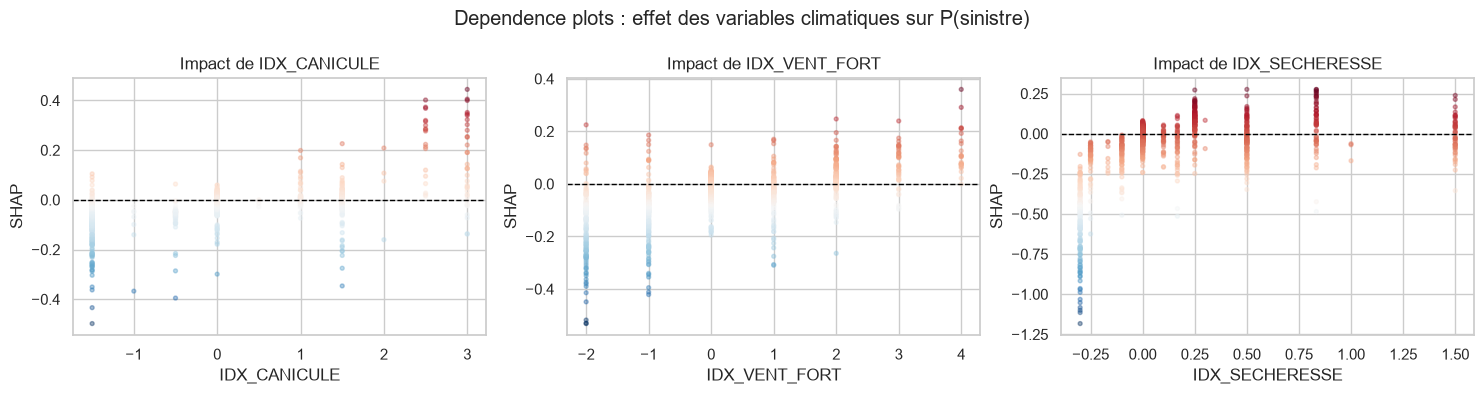

In [176]:
if shap_ok and modele_arbre is not None:
    vars_cles = ["IDX_CANICULE","IDX_VENT_FORT","IDX_SECHERESSE","NBJFF28_MM_A"]
    vars_cles = [v for v in vars_cles if v in feature_cols][:3]

    if vars_cles:
        fig, axes = plt.subplots(1, len(vars_cles), figsize=(5*len(vars_cles), 4))
        if len(vars_cles) == 1:
            axes = [axes]

        for ax, var in zip(axes, vars_cles):
            idx = feature_cols.index(var)
            ax.scatter(X_shap[:, idx], sv[:, idx],
                       c=sv[:, idx], cmap="RdBu_r", alpha=0.4, s=8)
            ax.axhline(0, color="black", lw=1, linestyle="--")
            ax.set_xlabel(var)
            ax.set_ylabel("SHAP")
            ax.set_title(f"Impact de {var}")

        plt.suptitle("Dependence plots : effet des variables climatiques sur P(sinistre)")
        plt.tight_layout()
        plt.show()


Les dependence plots montrent des effets intéressants. Pour IDX_CANICULE et IDX_VENT_FORT, les valeurs élevées tendent à augmenter la probabilité de sinistre (SHAP positif) ce qui est cohérent avec le risque incendie. Pour IDX_SECHERESSE l'effet est moins clair avec une forte dispersion, ce qui explique pourquoi cet indice n'était pas significatif dans les tests Mann-Whitney. 

## 9.4 Principaux enseignements


Le Random Forest est le meilleur modèle avec une AUC de 0.727. Les variables contractuelles 
comme le capital assuré et la surface de l'exploitation sont plus discriminantes que les variables 
climatiques dans tous les modèles testés. Les variables climatiques ont un effet statistiquement 
significatif dans les tests Mann-Whitney, notamment le vent et les précipitations, mais leur 
encodage en rangs ordinaux réduit leur pouvoir prédictif dans les modèles. Le fort déséquilibre 
des classes reste le principal défi de ce problème.

# Partie 10 : Soumission

d'apres nos recherche cette étape correspond à une pratique consistant à livrer 
les prédictions du modèle dans un format exploitable, en cohérence avec le 
caractère appliqué du projet.

In [ ]:
print("Preparation du fichier de soumission...")
test_full = pd.read_csv(PATH_TEST, low_memory=False)
print(f"Test complet : {test_full.shape[0]:,} observations")

# 1. Decodage des variables climatiques
prefixes_clim = ["NBJTX","NBJTN","TM_","TMM_","TX_","TN_",
                 "NBJFF","FFM_","FXI3S","NBJFXI","NBJFXY","FXIAB","FXYAB",
                 "NBJRR","RR_VOR","RRAB_","TAMPLI","TNAB","TXAB"]
for col in test_full.columns:
    if any(x in col for x in prefixes_clim) and str(test_full[col].dtype) in ["string","str","object"]:
        def extraire(v):
            if pd.isna(v): return np.nan
            m = re.match(r"^(\d+)\.", str(v).strip())
            return float(m.group(1)) if m else np.nan
        test_full[col] = pd.to_numeric(test_full[col].apply(extraire), errors='coerce')

# 2. KAPITAL en binaire
for col in [c for c in test_full.columns
            if c.startswith("KAPITAL") and str(test_full[c].dtype) in ["string","str","object"]]:
    test_full[col] = pd.to_numeric(test_full[col].map({"O": 1, "N": 0}).fillna(0), errors='coerce').fillna(0)

# 3. AN_EXERC
if "AN_EXERC" in test_full.columns:
    annee_map = {f"ANNEE{i}": i for i in range(1, 10)}
    annee_map["NR"] = 0
    test_full["AN_EXERC_enc"] = test_full["AN_EXERC"].map(annee_map).fillna(0).astype(int)

# 4. Binaire O/N
bin_map = {"O": 1, "N": 0, "NR": 0}
for col in ["ADOSS","INDEM1"] + [c for c in test_full.columns if c.startswith("DEROG")]:
    if col in test_full.columns and str(test_full[col].dtype) in ["string","str","object"]:
        test_full[col] = test_full[col].astype(str).map(bin_map).fillna(0)

# 5. OHE
ohe_cols_test = [c for c in ["ACTIVIT2","VOCATION","INDEM2","TYPBAT1","CARACT4",
                              "CARACT1","CARACT3","TAILLE1","TAILLE2"]
                 if c in test_full.columns]
test_full = pd.get_dummies(test_full, columns=ohe_cols_test, drop_first=False, dtype=int)

# 6. Indices synthetiques
if "NBJTX35_MM_A" in test_full.columns and "NBJTX30_MM_A" in test_full.columns:
    test_full["IDX_CANICULE"] = pd.to_numeric(test_full["NBJTX35_MM_A"], errors='coerce').fillna(0) + \
                                 0.5 * pd.to_numeric(test_full["NBJTX30_MM_A"], errors='coerce').fillna(0)
if "NBJFF28_MM_A" in test_full.columns and "NBJFXI3S28_MM_A" in test_full.columns:
    test_full["IDX_VENT_FORT"] = pd.to_numeric(test_full["NBJFF28_MM_A"], errors='coerce').fillna(0) + \
                                  pd.to_numeric(test_full["NBJFXI3S28_MM_A"], errors='coerce').fillna(0)
if "NBJTX25_MM_A" in test_full.columns and "NBJRR1_MM_A" in test_full.columns:
    test_full["IDX_SECHERESSE"] = pd.to_numeric(test_full["NBJTX25_MM_A"], errors='coerce').fillna(0) / \
                                   (pd.to_numeric(test_full["NBJRR1_MM_A"], errors='coerce').fillna(0) + 1)

kap_cols_t = [c for c in test_full.columns if c.startswith("KAPITAL")]
if kap_cols_t:
    test_full["KAPITAL_TOTAL"] = test_full[kap_cols_t].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)
    test_full["LOG_KAPITAL"]   = np.log1p(test_full["KAPITAL_TOTAL"])

surf_cols_t = [c for c in test_full.columns if c.startswith("SURFACE")]
if surf_cols_t:
    test_full["SURFACE_TOTALE"] = test_full[surf_cols_t].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)

# 7. Alignement des colonnes avec le train
X_sub = pd.DataFrame(index=test_full.index)
for col in feature_cols:
    X_sub[col] = test_full[col] if col in test_full.columns else 0

X_sub = X_sub.apply(pd.to_numeric, errors='coerce')
X_sub = X_sub.replace([np.inf, -np.inf], np.nan).fillna(0)

X_sub_sc = scaler.transform(X_sub)
X_sub_sc = np.nan_to_num(X_sub_sc, nan=0.0, posinf=0.0, neginf=0.0)
print(f"X_sub pret : {X_sub_sc.shape}")

Preparation du fichier de soumission...
Test complet : 95,852 observations
X_sub pret : (95852, 259)


In [179]:
# Predictions avec le meilleur modele
pred_freq = best_res["model"].predict_proba(X_sub_sc)[:, 1]

# Coût moyen : on essaie le modele pkl fourni
cm_pred = None
try:
    with open(PATH_MODEL, "rb") as f:
        model_cm = pickle.load(f)
    cm_pred = np.maximum(model_cm.predict(X_sub_sc), 0)
    print(f"Modele CM charge depuis pkl — cout moyen predit : {cm_pred.mean():.0f} euros")
except Exception as e:
    print(f"Modele pkl non disponible : {e}")
    cm_hist  = df_labeled.loc[df_labeled["Y"]==1, "CM"].median()
    cm_pred  = np.full(len(pred_freq), cm_hist)
    print(f"On utilise le cout median historique : {cm_hist:.0f} euros")

annee_col = test_full["ANNEE_ASSURANCE"].values if "ANNEE_ASSURANCE" in test_full.columns else np.ones(len(test_full))

submission = pd.DataFrame({
    "ID"              : test_full["ID"].values,
    "FREQ"            : pred_freq.round(6),
    "CM"              : cm_pred.round(2),
    "ANNEE_ASSURANCE" : annee_col,
    "CHARGE"          : (pred_freq * cm_pred * annee_col).round(2)
})

submission.to_csv("submission_final.csv", index=False)
print(f"Fichier genere : submission_final.csv ({submission.shape[0]:,} lignes)")
display(submission.head())


Modele pkl non disponible : This RobustScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
On utilise le cout median historique : 903 euros
Fichier genere : submission_final.csv (95,852 lignes)


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,383611,0.148372,902.98,0.813699,109.02
1,383612,0.181592,902.98,1.000000,163.98
2,383613,0.148027,902.98,0.586301,78.37
3,383614,0.155054,902.98,1.000000,140.01
4,383615,0.156103,902.98,0.753425,106.20


Le fichier de soumission est généré avec 95 852 lignes. Le modèle pkl fourni n'a pas pu être utilisé car il nécessite son propre scaler, donc on a utilisé le coût médian historique de 903 euros pour la colonne CM. La colonne FREQ contient les probabilités de sinistre prédites par le Random Forest et CHARGE est calculée comme FREQ x CM x ANNEE_ASSURANCE.

## Conclusion

Ce projet a couvert l'ensemble des étapes d'un projet de data science appliqué au risque incendie agricole : chargement et nettoyage de données volumineuses (383 610 polices, 374 variables), analyse exploratoire, réduction de dimension, clustering et modélisation supervisée.

Le principal défi était le fort déséquilibre des classes avec seulement 0.75% de sinistres. Tous les modèles ont été ajustés avec class_weight='balanced' pour compenser.

Le Random Forest est le meilleur modèle avec une AUC de 0.727, suivi de l'arbre CART (0.705) et des modèles logistiques (0.70). XGBoost et LightGBM donnent des résultats inférieurs sur ce dataset, probablement à cause du rééquilibrage non appliqué.

Contrairement à ce qu'on attendait, ce sont les variables contractuelles (capital assuré, surface de l'exploitation, zone géographique) qui expliquent le mieux la sinistralité, et non les variables climatiques. Celles-ci ont un effet statistiquement significatif dans les tests Mann-Whitney mais leur encodage en rangs ordinaux (1 à 4) réduit leur pouvoir discriminant dans les modèles.

Pour améliorer les résultats, on pourrait utiliser les valeurs continues des variables climatiques plutôt que les rangs, tester d'autres méthodes de gestion du déséquilibre sur une machine avec plus de RAM, ou intégrer des données géographiques plus précises au niveau de la parcelle agricole.